# Attention-Based CNN and RCNN Models for Wheat Futures Price Forecasting

## Goal

The goal here is to predict tomorrow's wheat futures price using today's macroeconomic data. We have about 16 years of daily wheat prices (2008-2024) and 32 economic indicators from the FRED-MD database — things like interest rates, exchange rates, oil prices, consumer sentiment, and so on.

The question we kept asking ourselves was: **what's the right neural network architecture for this problem?** Time series forecasting with external features is tricky. You need a model that can pick up on patterns across time, but also one that doesn't overfit to noise in the training data.

---

## The Thinking Behind Our Architecture Choices

We landed on testing four different architectures, and here's the reasoning:

**The first decision was CNN vs RCNN.** We know convolutional networks work remarkably well on images, so the natural question was: can they handle price data? Images are highly structured — pixels have fixed spatial relationships, edges and textures follow predictable patterns. Financial time series are messier. Prices jump around, trends reverse unexpectedly, and the "patterns" aren't nearly as clean as what you'd find in image data. We wanted to see if CNNs could still pick up on whatever local structure exists in the 30-day price windows. And we added recurrent layers (GRU) in some models to see if explicit sequential memory would help capture trends that build up over time.

**The second decision was about attention.** We tested both CNN and RCNN architectures with and without attention mechanisms. The baseline versions just use global average pooling — treating all 30 days equally when making a prediction. But intuitively, not all days should matter the same. Maybe what happened yesterday matters more than what happened three weeks ago, or maybe there's a specific pattern from two weeks back that's relevant. Attention mechanisms let the model learn these weights instead of us having to specify them.

We tried two types of attention:

1. **Self-attention** (using the SeqSelfAttention layer) computes relationships between every pair of timesteps. If day 5 and day 25 in your 30-day window are somehow related, self-attention can learn that.

2. **Temporal attention pooling** is simpler — it just learns a weight for each timestep and takes a weighted average. It's asking "which days matter most?" but not "how do days relate to each other?"

So we ended up testing multiple combinations: CNN with self-attention, CNN with temporal attention pooling, RCNN with self-attention, RCNN with temporal attention pooling, and baseline versions without attention for comparison.

---

## Results

| Model | Test RMSE | Test R² |
|-------|-----------|---------|
| CNN with Self-Attention | 78.67 | 0.765 |
| RCNN with Temporal Attention | 88.02 | 0.705 |
| CNN with Temporal Attention | 148.49 | 0.162 |
| RCNN with Self-Attention | 155.01 | 0.087 |

The CNN with self-attention won, and it wasn't particularly close.

---

## My Reasoning:

**The RCNN models underperformed, which surprised us.** The conventional wisdom is that recurrent layers help with sequential data. But looking at the results, adding GRU layers actually hurt. My intuition is that the 30-day lookback window just isn't long enough to need recurrent memory. A CNN with a kernel size of 3-5 can already "see" patterns across 10-15 days when you stack a few layers. The GRU added a lot of parameters (roughly 3x more than the CNN-only models) but didn't add much useful capacity — it just gave the model more room to overfit.

**Self-attention worked better than temporal attention pooling.** This makes sense when you think about it. Temporal attention answers the question "which days should I pay attention to?" Self-attention answers "how does each day relate to every other day?" For commodity prices, relationships between different points in time might matter. Maybe a spike in oil prices two weeks ago is related to what's happening with interest rates today. Self-attention can pick up on that; temporal pooling can't.

**The generalization gap tells an interesting story.** All models fit the training data well (R² around 0.92-0.95), but they diverged on the test set. The CNN with self-attention only degraded by about 2x from train to test, while the RCNN with self-attention degraded by nearly 4x. Simpler models generalized better.

---

## The Overfitting Problem

One thing that stood out: the RCNN with temporal attention had the *best* validation performance (R² = 0.92) but only came in second on the test set. This is a good reminder that validation metrics can be misleading, especially in time series where the test period might look different from the validation period.

The test set covers 2023-2024, which includes some unusual market conditions — post-COVID recovery, the Ukraine war disrupting grain supply chains, aggressive interest rate hikes. Models that fit the training data too closely couldn't adapt to these regime changes.

---

## What We Learned

1. **Simpler architectures can beat complex ones.** We expected the RCNN models to do better because they have more capacity. They didn't. The extra parameters became a liability.

2. **Attention type matters.** Self-attention's ability to model pairwise relationships was clearly more valuable than temporal pooling's simpler weighting scheme.

3. **Watch the generalization gap.** A model that looks great on validation can still fail on truly out-of-sample data. The CNN with self-attention had modest validation numbers but held up better when it mattered.

4. **Don't over-engineer for short sequences.** With only 30 timesteps, you don't need the heavy machinery of recurrent networks. Convolutions plus attention were enough.

---

## Data and Setup

For context on the experimental setup:

We used daily wheat futures prices from Investing.com going back to 2008, combined with 32 macroeconomic features from FRED-MD. The features cover interest rates (fed funds, treasuries, corporate bonds), exchange rates, oil prices, consumer sentiment, and various economic indicators.

The FRED data is monthly, so we forward-filled it to daily frequency. We also shifted it by one month to avoid look-ahead bias — you wouldn't know August's economic data until sometime in September.

For training, we used a 30-day lookback window, an 80/20 train-test split (time-ordered, no shuffling), and 5-fold time series cross-validation for hyperparameter tuning. All models were optimized with Optuna using 50 trials each.

---

## Take aways:

If you're building a model to forecast agricultural commodity prices using macroeconomic data, I would suggest starting simple: a CNN stack with self-attention. Skip the recurrent layers unless you have a much longer lookback window . And pay attention to how your model degrades from train to test — that gap tells more about real-world performance than validation accuracy does.


#Without Optuna

In [ ]:
! pip install tensorflow
! pip install keras-self-attention
! pip install optuna

  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18895 sha256=98c908c2340f52279038d5defe8bd1b0d55833c33eafad5f20bc3aa55358b234
  Stored in directory: /root/.cache/pip/wheels/9a/9d/6e/09a0f61c2edeaea9f96fecdc67f31455c363bb44a4ddabe746
Successfully built keras-self-attention
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 38.2 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import layers, regularizers, Input, Model, optimizers
from keras_self_attention import SeqSelfAttention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import seaborn as sns
import tensorflow as tf
import optuna
import gc
from tensorflow.keras import backend as K


In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2018.csv')
df1['Date'] = pd.to_datetime(df1['Date'])
df1 = df1.set_index('Date', drop=True)
df1.sort_index(inplace=True)
df1['Price'] = df1['Price'].str.replace(',', '').astype('float64')
#df.to_csv('US Wheat Futures Historical Data.csv')
df1_price = df1['Price']
df1_price

,Price
Date,
1999-08-01,264.75
1999-08-02,282.75
1999-08-03,272.00
1999-08-04,276.50
1999-08-05,278.50
...,...
2018-09-03,538.75
2018-09-04,502.75
2018-09-05,493.75


In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/Quants /Investing.com/US Wheat Futures Historical Data_2025.csv')
df2['Date'] = pd.to_datetime(df2['Date'])
df2 = df2.set_index('Date', drop=True)
df2.sort_index(inplace=True)
df2['Price'] = df2['Price'].str.replace(',', '').astype('float64')
#df.to_csv('US Wheat Futures Historical Data.csv')
df2_price = df2['Price']
df2_price

,Price
Date,
2018-09-07,486.25
2018-09-10,504.00
2018-09-11,493.75
2018-09-12,481.75
2018-09-13,471.75
...,...
2025-12-08,534.75
2025-12-09,534.50
2025-12-10,529.50


In [ ]:
df = pd.concat([df1, df2.iloc[1:]])

df.to_csv('US Wheat Futures Historical Data.csv')
print("Head of merged DataFrame:")
print(df.head())
print("\nTail of merged DataFrame:")
print(df.tail())


df_price = df['Price']
df_price



Head of merged DataFrame:
             Price    Open    High     Low     Vol. Change %
Date                                                        
1999-08-01  264.75  264.00  286.75  259.00  160.06K    0.38%
1999-08-02  282.75  264.00  283.75  264.00   17.64K    6.80%
1999-08-03  272.00  282.00  286.75  271.00   14.02K   -3.80%
1999-08-04  276.50  271.25  276.75  269.00    4.98K    1.65%
1999-08-05  278.50  276.50  279.00  271.50    9.30K    0.72%

Tail of merged DataFrame:
             Price    Open    High     Low    Vol. Change %
Date                                                       
2025-12-08  534.75  535.25  540.00  532.50  49.77K   -0.19%
2025-12-09  534.50  535.50  537.75  531.25  54.30K   -0.05%
2025-12-10  529.50  534.00  535.00  525.25  68.63K   -0.94%
2025-12-11  533.50  529.75  534.75  529.25  62.42K    0.76%
2025-12-12  530.50  534.50  536.00  529.10  24.57K   -0.56%


,Price
Date,
1999-08-01,264.75
1999-08-02,282.75
1999-08-03,272.00
1999-08-04,276.50
1999-08-05,278.50
...,...
2025-12-08,534.75
2025-12-09,534.50
2025-12-10,529.50


In [ ]:
df_features = pd.read_csv('/content/drive/MyDrive/Quants /FredMD_Dataset/FRED.csv')
df_features = df_features.dropna(how='all', axis=1)
features_missing = []

for col in df_features.columns:
    if col == "Month":
        continue
    s = df_features[col].isna() | (df_features[col] == "")
    if not s.any():
        continue

    features_missing.append(col)

df_features['Month'] = pd.to_datetime(df_features['Month'])
df_features = df_features.set_index('Month').sort_index()
df_selected = df_features.drop(columns=features_missing)
features = [
    "RPI", "W875RX1", "CMRMTSPLx",
    "IPFPNSS", "USWTRADE",
    "USTRADE", "BUSLOANS", "CONSPI", "S&P 500",
    "S&P PE ratio", "FEDFUNDS", "TB3MS", "TB6MS", "GS1", "GS5",
    "GS10", "AAA", "BAA", "TB3SMFFM", "TB6SMFFM", "T1YFFM",
    "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",
    "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx", "OILPRICEx",
    "PPICMM", "UMCSENTx"
]

df_features = df_features[features]
df_features

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,OILPRICEx,PPICMM,UMCSENTx
Month,,,,,,,,,,,,,,,,,,,,,
1999-08-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
1999-09-01,3842.561807,3321.054004,434465.878601,76.647955,4924.282787,14716.772541,488.191875,0.131016,243.143463,15.946036,...,0.765184,1.459590,2.446885,2.685952,245.311656,2.078418,1.164706,14.435947,84.190164,86.923054
1999-10-01,3848.215369,3325.640164,435231.819302,76.748350,4928.615542,14733.366053,489.693146,0.130962,245.341881,15.946036,...,0.765051,1.461043,2.447975,2.683581,245.028555,2.077490,1.165345,14.455260,84.245808,86.983582
1999-11-01,7120.796970,5617.389362,435231.819302,76.878239,4932.944898,14749.936735,491.519876,0.129403,247.494265,16.060393,...,0.765347,1.462857,2.449469,2.681144,244.744752,2.076632,1.165982,14.471963,84.305102,87.031845
1999-12-01,4191.127291,4126.544304,435231.819302,76.987908,4937.331976,14766.598778,493.105573,0.129341,249.823198,16.060393,...,0.765031,1.463829,2.450041,2.678849,244.459423,2.075703,1.166596,14.493344,84.370265,87.091691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,9492.169116,8090.965184,820836.295036,71.747139,4775.909784,11914.240915,842.746761,0.135582,925.983875,19.389145,...,1.003685,2.001372,3.001321,2.088519,193.962642,1.870707,1.197099,32.890892,126.494198,85.244708
2024-09-01,9519.405260,8109.921193,822489.552603,71.782490,4777.690102,11918.954061,845.149648,0.135488,931.760812,19.422432,...,1.000558,1.998249,2.997855,2.086957,193.902111,1.869976,1.197313,32.946462,126.678704,85.217350
2024-10-01,9532.882349,8120.457541,821633.252409,71.819452,4779.453739,11923.708238,847.602589,0.135506,937.704411,19.422432,...,0.997503,1.995146,2.994423,2.085386,193.837538,1.869281,1.197512,32.993729,126.864238,85.193543


In [ ]:
df_features = df_features.shift(periods=1, freq='infer').dropna()   # shift index by one month forward

# 2. Compute new daily date range covering the full span
start = df_features.index.min().replace(day=1)
end = (df_features.index.max() + pd.offsets.MonthEnd(0))
all_days = pd.date_range(start, end, freq='D')

# 3. Reindex to daily frequency and forward-fill missing values
df_features = df_features.reindex(all_days).ffill()
df_features.to_csv('features.csv')
df_features

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,OILPRICEx,PPICMM,UMCSENTx
1999-09-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
1999-09-02,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
1999-09-03,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
1999-09-04,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
1999-09-05,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451
2025-01-28,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451
2025-01-29,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451
2025-01-30,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451


In [ ]:
df_all = df_features.join(df_price, how='inner')
df_all

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,OILPRICEx,PPICMM,UMCSENTx,Price
1999-09-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270,266.75
1999-09-02,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270,270.75
1999-09-03,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270,272.75
1999-09-07,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270,277.00
1999-09-08,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270,269.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,535.50
2025-01-28,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,545.25
2025-01-29,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,562.50
2025-01-30,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,566.50


In [ ]:
df_all = df_all['2008-01-01':]
df_all

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,OILPRICEx,PPICMM,UMCSENTx,Price
2008-01-01,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,19.162763,96.012947,88.098614,929.50
2008-01-02,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,19.162763,96.012947,88.098614,915.00
2008-01-03,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,19.162763,96.012947,88.098614,945.00
2008-01-04,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,19.162763,96.012947,88.098614,931.50
2008-01-07,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,19.162763,96.012947,88.098614,903.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,535.50
2025-01-28,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,545.25
2025-01-29,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,562.50
2025-01-30,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,566.50


In [ ]:
lookback = 30

data = df_all.values
X, y = [], []
for i in range(len(data) - lookback):
    seq_x = data[i : i + lookback, :]          # past 30 days of all features + price
    target = data[i + lookback, -1]
    X.append(seq_x)
    y.append(target)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4458, 30, 33)
y shape: (4458,)


In [ ]:
df_all['Price']

,Price
2008-01-01,929.50
2008-01-02,915.00
2008-01-03,945.00
2008-01-04,931.50
2008-01-07,903.00
...,...
2025-01-27,535.50
2025-01-28,545.25
2025-01-29,562.50
2025-01-30,566.50


<Axes: >

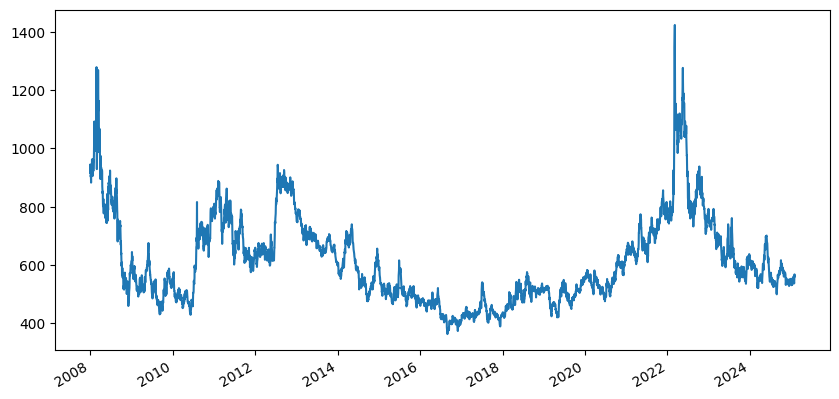

In [ ]:
df_all['Price'].plot(figsize=(10, 5))

In [ ]:
def build_cnn_with_self_attention(
    seq_length: int = 30,
    feature_dim: int = 33,

    # "Encoder" params (CNN stack)
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 3,
    dropout: float = 0.2,
    kernel_reg: float = 0.02,

    # Keep these args so your cv_train_gru call doesn't break
    encoder_bidirectional: bool = False,   # unused for CNN
    use_attention: bool = False,
    attention_activation: str = "sigmoid",

    # Head params
    dense_units: int = 128,
    output_activation: str = "linear",

    # kept for signature parity (you compile outside anyway)
    learning_rate: float = 1e-3
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))
    x = inputs

    # Conv1D stack
    for i in range(n_conv_layers):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",  # or "causal" if you want strictly past->future
            activation="relu",
            kernel_regularizer=regularizers.l2(kernel_reg),
        )(x)
        x = layers.Dropout(dropout)(x)

    # Optional self-attention (works because x is still (B, T, C))
    if use_attention:
        x = SeqSelfAttention(attention_activation=attention_activation)(x)

        # (optional but often helpful) residual + norm
        x = layers.LayerNormalization()(x)

    # Pool over time -> fixed vector
    x = layers.GlobalAveragePooling1D()(x)

    # Dense head
    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        1,
        activation=output_activation,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)

    return Model(inputs, outputs)



In [ ]:



# -----------------------------
# Scaling helpers (better than flattening)
# -----------------------------
def fit_x_scaler_3d(X_3d: np.ndarray) -> StandardScaler:
    """
    Fit a StandardScaler feature-wise across all timesteps.
    X: (N, T, F) -> fit on (N*T, F)
    """
    n_features = X_3d.shape[2]
    scaler = StandardScaler()
    scaler.fit(X_3d.reshape(-1, n_features))
    return scaler


def transform_x_scaler_3d(scaler: StandardScaler, X_3d: np.ndarray) -> np.ndarray:
    n_features = X_3d.shape[2]
    X_scaled = scaler.transform(X_3d.reshape(-1, n_features))
    return X_scaled.reshape(X_3d.shape)


def fit_y_scaler(y: np.ndarray) -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(y.reshape(-1, 1))
    return scaler


def transform_y(scaler: StandardScaler, y: np.ndarray) -> np.ndarray:
    return scaler.transform(y.reshape(-1, 1))


def inverse_y(scaler: StandardScaler, y_scaled: np.ndarray) -> np.ndarray:
    return scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(-1)


# -----------------------------
# Naive baseline (persistence): predict y_t ≈ y_{t-1}
# -----------------------------
def naive_persistence_rmse(y_train: np.ndarray, y_test: np.ndarray) -> float:
    y_pred = np.empty_like(y_test, dtype=float)
    y_pred[0] = y_train[-1]
    y_pred[1:] = y_test[:-1]
    return float(np.sqrt(mean_squared_error(y_test, y_pred)))


# -----------------------------
# CV training (keeps best fold model + correct scalers)
# -----------------------------
def cv_train_timeseries_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_origin,
    encoder_bidirectional: bool = False,
    use_attention: bool = False,
    n_splits: int = 5,
    max_train_size: int = None,
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3,
    plot_test: bool = True
):
    """
    - Fits scalers per fold on X_tr/y_tr
    - Keeps the fold with lowest val_loss as 'best'
    - Evaluates test using THAT fold's scalers (no mismatch)
    """
    tscv = TimeSeriesSplit(n_splits=n_splits, max_train_size=max_train_size)

    best = {
        "val_loss": np.inf,
        "model": None,
        "x_scaler": None,
        "y_scaler": None,
        "fold": None
    }

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        print(f"=== Fold {fold} ===")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # Fit scalers on training part only
        x_scaler = fit_x_scaler_3d(X_tr)
        X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
        X_val_s = transform_x_scaler_3d(x_scaler, X_val)

        y_scaler = fit_y_scaler(y_tr)
        y_tr_s = transform_y(y_scaler, y_tr)
        y_val_s = transform_y(y_scaler, y_val)

        model = model_origin(
            encoder_bidirectional=encoder_bidirectional,
            use_attention=use_attention
        )
        model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss="mean_squared_error"
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=early_stop_patience,
            restore_best_weights=True,
            verbose=0
        )
        reduce_lr = ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        )

        hist = model.fit(
            X_tr_s, y_tr_s,
            validation_data=(X_val_s, y_val_s),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        fold_best_val = float(np.min(hist.history["val_loss"]))
        if fold_best_val < best["val_loss"]:
            best.update({
                "val_loss": fold_best_val,
                "model": model,
                "x_scaler": x_scaler,
                "y_scaler": y_scaler,
                "fold": fold
            })

    # ---- Test eval using BEST fold's scalers ----
    model = best["model"]
    X_test_s = transform_x_scaler_3d(best["x_scaler"], X_test)

    y_pred_scaled = model.predict(X_test_s, verbose=0).reshape(-1)
    y_pred = inverse_y(best["y_scaler"], y_pred_scaled)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2 = float(r2_score(y_test, y_pred))

    print("\n=== Best fold selected ===")
    print(f"Fold: {best['fold']} | best val_loss: {best['val_loss']:.6f}")
    print("\n=== Test set performance (best fold scalers) ===")
    print(f"Test RMSE: {rmse:.6f}")
    print(f"Test R²  : {r2:.6f}")

    if plot_test:
        plt.figure(figsize=(10, 5))
        plt.plot(y_test, label="Actual (test)")
        plt.plot(y_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted")
        plt.legend()
        plt.show()

    return model, best["x_scaler"], best["y_scaler"], y_pred, {"rmse": rmse, "r2": r2}


# -----------------------------
# Final retrain on ALL training data (recommended after CV)
# -----------------------------
def train_final_model_and_eval(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_origin,
    encoder_bidirectional: bool = False,
    use_attention: bool = False,
    val_fraction: float = 0.1,   # last 10% used for validation
    early_stop_patience: int = 10,
    epochs: int = 200,
    batch_size: int = 64,
    learning_rate: float = 1e-3,
    plot_test: bool = True
):
    """
    Fits scalers on ALL X_train/y_train, trains final model on ALL train
    (with a small tail validation split), evaluates on test consistently.
    """
    # Fit scalers on full training set
    x_scaler = fit_x_scaler_3d(X_train)
    X_train_s = transform_x_scaler_3d(x_scaler, X_train)
    X_test_s = transform_x_scaler_3d(x_scaler, X_test)

    y_scaler = fit_y_scaler(y_train)
    y_train_s = transform_y(y_scaler, y_train)

    model = model_origin(
        encoder_bidirectional=encoder_bidirectional,
        use_attention=use_attention
    )
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="mean_squared_error"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=early_stop_patience,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )

    model.fit(
        X_train_s, y_train_s,
        validation_split=val_fraction,
        shuffle=False,  # IMPORTANT for time series: keeps tail as validation
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    y_pred_scaled = model.predict(X_test_s, verbose=0).reshape(-1)
    y_pred = inverse_y(y_scaler, y_pred_scaled)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2 = float(r2_score(y_test, y_pred))

    print("\n=== Final retrain performance ===")
    print(f"Test RMSE: {rmse:.6f}")
    print(f"Test R²  : {r2:.6f}")

    if plot_test:
        plt.figure(figsize=(10, 5))
        plt.plot(y_test, label="Actual (test)")
        plt.plot(y_pred, label="Predicted (test)")
        plt.title("Final model: Actual vs Predicted (test)")
        plt.legend()
        plt.show()

    return model, x_scaler, y_scaler, y_pred, {"rmse": rmse, "r2": r2}


In [ ]:

test_size = int(X.shape[0]*0.2)

X_train = X[: -test_size]
y_train = y[: -test_size]

X_test = X[-test_size : ]
y_test = y[-test_size : ]

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

print("Naive RMSE:", naive_persistence_rmse(y_train, y_test))

# 1) CV (select hyperparams / sanity check)

Training set: (3567, 30, 33) (3567,)
Test set: (891, 30, 33) (891,)
Naive RMSE: 20.37058897464582


In [ ]:

cv_model, cv_xs, cv_ys, cv_pred, cv_metrics = cv_train_timeseries_model(
    X_train, y_train, X_test, y_test,
    model_origin=build_cnn_with_self_attention,
    use_attention=True
)

# 2) Final retrain on all training data (best practice)
final_model, xs, ys, yhat, metrics = train_final_model_and_eval(
    X_train, y_train, X_test, y_test,
    model_origin=build_cnn_with_self_attention,
    use_attention=True
)


=== Fold 1 ===


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Input, Model

class TemporalAttentionPooling(layers.Layer):
    """
    Learns attention weights over time steps and returns a weighted sum.
    Input:  x  shape (B, T, C)
    Output: ctx shape (B, C)
    """
    def __init__(self, attn_units: int = 64, **kwargs):
        super().__init__(**kwargs)
        self.attn_units = attn_units
        self.W = layers.Dense(attn_units, activation="tanh")
        self.v = layers.Dense(1, activation=None)

    def call(self, x):
        # scores: (B, T, 1)
        scores = self.v(self.W(x))
        # weights: (B, T, 1) softmax across time
        weights = tf.nn.softmax(scores, axis=1)
        # context: (B, C)
        context = tf.reduce_sum(weights * x, axis=1)
        return context


def build_cnn_with_attention(
    seq_length: int = 30,
    feature_dim: int = 33,

    # CNN stack
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 3,
    dropout: float = 0.2,
    kernel_reg: float = 0.02,

    # kept for compatibility
    encoder_bidirectional: bool = False,   # unused here
    use_attention: bool = True,            # attention pooling on/off

    # attention pooling params
    attn_units: int = 64,

    # head
    dense_units: int = 128,
    output_activation: str = "linear",

    # kept for signature parity
    learning_rate: float = 1e-3
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))
    x = inputs

    # Conv1D stack -> (B, T, C)
    for _ in range(n_conv_layers):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",   # or "causal"
            activation="relu",
            kernel_regularizer=regularizers.l2(kernel_reg),
        )(x)
        x = layers.Dropout(dropout)(x)

    # Attention pooling over time OR average pooling
    if use_attention:
        x = TemporalAttentionPooling(attn_units=attn_units)(x)  # (B, C)
    else:
        x = layers.GlobalAveragePooling1D()(x)                  # (B, C)

    # Dense head
    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        1,
        activation=output_activation,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)

    return Model(inputs, outputs)

cv_model, cv_xs, cv_ys, cv_pred, cv_metrics = cv_train_timeseries_model(
    X_train, y_train, X_test, y_test,
    model_origin=build_cnn_with_attention,
    use_attention=True
)

final_model, xs, ys, yhat, metrics = train_final_model_and_eval(
    X_train, y_train, X_test, y_test,
    model_origin=build_cnn_with_attention,
    use_attention=True
)



In [ ]:
class TemporalAttentionPooling(layers.Layer):
    def __init__(self, attn_units: int = 64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(attn_units, activation="tanh")
        self.v = layers.Dense(1, activation=None)

    def call(self, x):
        scores = self.v(self.W(x))                 # (B, T, 1)
        weights = tf.nn.softmax(scores, axis=1)    # (B, T, 1)
        return tf.reduce_sum(weights * x, axis=1)  # (B, C)

def build_cnn_with_attention(
    seq_length: int,
    feature_dim: int,
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 3,
    dropout: float = 0.2,
    kernel_reg: float = 0.02,
    encoder_bidirectional: bool = False,  # unused
    use_attention: bool = True,
    attn_units: int = 64,
    dense_units: int = 128,
    output_activation: str = "linear",
    learning_rate: float = 1e-3
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))
    x = inputs

    for _ in range(n_conv_layers):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(kernel_reg),
        )(x)
        x = layers.Dropout(dropout)(x)

    x = TemporalAttentionPooling(attn_units=attn_units)(x) if use_attention else layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(dense_units, activation="relu",
                     kernel_regularizer=regularizers.l2(kernel_reg))(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(1, activation=output_activation,
                           kernel_regularizer=regularizers.l2(kernel_reg))(x)

    return Model(inputs, outputs)
def cv_train_timeseries_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_origin,
    encoder_bidirectional: bool = False,
    use_attention: bool = False,
    n_splits: int = 5,
    max_train_size: int = None,
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3,
    plot_test: bool = True
):
    tscv = TimeSeriesSplit(n_splits=n_splits, max_train_size=max_train_size)

    best = {"val_loss": np.inf, "model": None, "x_scaler": None, "y_scaler": None, "fold": None}

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        print(f"=== Fold {fold} ===")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        x_scaler = fit_x_scaler_3d(X_tr)
        X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
        X_val_s = transform_x_scaler_3d(x_scaler, X_val)

        y_scaler = fit_y_scaler(y_tr)
        y_tr_s = transform_y(y_scaler, y_tr)
        y_val_s = transform_y(y_scaler, y_val)

        model = model_origin(encoder_bidirectional=encoder_bidirectional, use_attention=use_attention)
        model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate), loss="mean_squared_error")

        early_stop = EarlyStopping(monitor="val_loss", patience=early_stop_patience,
                                   restore_best_weights=True, verbose=0)
        reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                                      min_lr=1e-6, verbose=0)

        hist = model.fit(
            X_tr_s, y_tr_s,
            validation_data=(X_val_s, y_val_s),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        fold_best_val = float(np.min(hist.history["val_loss"]))
        if fold_best_val < best["val_loss"]:
            best.update({"val_loss": fold_best_val, "model": model,
                         "x_scaler": x_scaler, "y_scaler": y_scaler, "fold": fold})

    model = best["model"]
    X_test_s = transform_x_scaler_3d(best["x_scaler"], X_test)
    y_pred_scaled = model.predict(X_test_s, verbose=0).reshape(-1)
    y_pred = inverse_y(best["y_scaler"], y_pred_scaled)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2 = float(r2_score(y_test, y_pred))

    print("\n=== Best fold selected ===")
    print(f"Fold: {best['fold']} | best val_loss: {best['val_loss']:.6f}")
    print("\n=== Test set performance (best fold scalers) ===")
    print(f"Test RMSE: {rmse:.6f}")
    print(f"Test R²  : {r2:.6f}")

    if plot_test:
        plt.figure(figsize=(10, 5))
        plt.plot(y_test, label="Actual (test)")
        plt.plot(y_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted")
        plt.legend()
        plt.show()

    return model, best["x_scaler"], best["y_scaler"], y_pred, {"rmse": rmse, "r2": r2}


def train_final_model_and_eval(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_origin,
    encoder_bidirectional: bool = False,
    use_attention: bool = False,
    val_fraction: float = 0.1,
    early_stop_patience: int = 10,
    epochs: int = 200,
    batch_size: int = 64,
    learning_rate: float = 1e-3,
    plot_test: bool = True
):
    x_scaler = fit_x_scaler_3d(X_train)
    X_train_s = transform_x_scaler_3d(x_scaler, X_train)
    X_test_s = transform_x_scaler_3d(x_scaler, X_test)

    y_scaler = fit_y_scaler(y_train)
    y_train_s = transform_y(y_scaler, y_train)

    model = model_origin(encoder_bidirectional=encoder_bidirectional, use_attention=use_attention)
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate), loss="mean_squared_error")

    early_stop = EarlyStopping(monitor="val_loss", patience=early_stop_patience,
                               restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                                  min_lr=1e-6, verbose=0)

    model.fit(
        X_train_s, y_train_s,
        validation_split=val_fraction,
        shuffle=False,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    y_pred_scaled = model.predict(X_test_s, verbose=0).reshape(-1)
    y_pred = inverse_y(y_scaler, y_pred_scaled)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2 = float(r2_score(y_test, y_pred))

    print("\n=== Final retrain performance ===")
    print(f"Test RMSE: {rmse:.6f}")
    print(f"Test R²  : {r2:.6f}")

    if plot_test:
        plt.figure(figsize=(10, 5))
        plt.plot(y_test, label="Actual (test)")
        plt.plot(y_pred, label="Predicted (test)")
        plt.title("Final model: Actual vs Predicted (test)")
        plt.legend()
        plt.show()

    return model, x_scaler, y_scaler, y_pred, {"rmse": rmse, "r2": r2}

print("Naive RMSE:", naive_persistence_rmse(y_train, y_test))

T, F = X_train.shape[1], X_train.shape[2]
model_origin_attn = lambda encoder_bidirectional=False, use_attention=True: build_cnn_with_attention(
    seq_length=T, feature_dim=F,
    encoder_bidirectional=encoder_bidirectional,
    use_attention=use_attention
)

cv_model, cv_xs, cv_ys, cv_pred, cv_metrics = cv_train_timeseries_model(
    X_train, y_train, X_test, y_test,
    model_origin=model_origin_attn,
    use_attention=True
)

final_model, xs, ys, yhat, metrics = train_final_model_and_eval(
    X_train, y_train, X_test, y_test,
    model_origin=model_origin_attn,   # SAME model as CV
    use_attention=True
)


In [ ]:
from tensorflow.keras import layers, regularizers, Input, Model

def build_rcnn_no_attention(
    seq_length: int,
    feature_dim: int,

    # CNN front-end
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,
    dropout: float = 0.2,
    kernel_reg: float = 0.02,

    # RNN back-end
    rnn_units: int = 64,
    encoder_bidirectional: bool = False,  # if True -> BiGRU
    use_attention: bool = False,          # kept for compatibility; ignored here

    # head
    dense_units: int = 128,
    output_activation: str = "linear",

    # kept for signature parity
    learning_rate: float = 1e-3
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))
    x = inputs

    # Conv1D stack -> (B, T, C)
    for _ in range(n_conv_layers):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",   # or "causal"
            activation="relu",
            kernel_regularizer=regularizers.l2(kernel_reg),
        )(x)
        x = layers.Dropout(dropout)(x)

    # GRU over time -> (B, rnn_units)  (or (B, 2*rnn_units) if bidir)
    gru = layers.GRU(
        rnn_units,
        return_sequences=False,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )
    if encoder_bidirectional:
        x = layers.Bidirectional(gru)(x)
    else:
        x = gru(x)

    # Dense head
    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        1,
        activation=output_activation,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)

    return Model(inputs, outputs)
print("Naive RMSE:", naive_persistence_rmse(y_train, y_test))

T, F = X_train.shape[1], X_train.shape[2]

model_origin_rcnn = lambda encoder_bidirectional=False, use_attention=False: build_rcnn_no_attention(
    seq_length=T, feature_dim=F,
    encoder_bidirectional=encoder_bidirectional,
    use_attention=use_attention
)

# 1) CV
cv_model, cv_xs, cv_ys, cv_pred, cv_metrics = cv_train_timeseries_model(
    X_train, y_train, X_test, y_test,
    model_origin=model_origin_rcnn,
    encoder_bidirectional=False,   # set True if you want BiGRU
    use_attention=False
)

# 2) Final retrain (same architecture as CV)
final_model, xs, ys, yhat, metrics = train_final_model_and_eval(
    X_train, y_train, X_test, y_test,
    model_origin=model_origin_rcnn,
    encoder_bidirectional=False,
    use_attention=False
)


In [ ]:

# If you already defined this earlier, you can reuse it as-is.
class TemporalAttentionPooling(layers.Layer):
    def __init__(self, attn_units: int = 64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(attn_units, activation="tanh")
        self.v = layers.Dense(1, activation=None)

    def call(self, x):
        scores = self.v(self.W(x))              # (B, T, 1)
        weights = tf.nn.softmax(scores, axis=1) # (B, T, 1)
        return tf.reduce_sum(weights * x, axis=1)  # (B, C)


def build_rcnn_with_attention(
    seq_length: int,
    feature_dim: int,

    # CNN front-end
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,
    dropout: float = 0.2,
    kernel_reg: float = 0.02,

    # RNN back-end
    rnn_units: int = 64,
    encoder_bidirectional: bool = False,
    use_attention: bool = True,

    # Attention pooling params
    attn_units: int = 64,

    # head
    dense_units: int = 128,
    output_activation: str = "linear",

    # kept for signature parity
    learning_rate: float = 1e-3
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))
    x = inputs

    # Conv1D stack -> (B, T, C)
    for _ in range(n_conv_layers):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",  # or "causal"
            activation="relu",
            kernel_regularizer=regularizers.l2(kernel_reg),
        )(x)
        x = layers.Dropout(dropout)(x)

    # GRU -> keep sequence for attention: (B, T, H)
    gru = layers.GRU(
        rnn_units,
        return_sequences=True,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )
    if encoder_bidirectional:
        x = layers.Bidirectional(gru)(x)  # (B, T, 2H)
    else:
        x = gru(x)                        # (B, T, H)

    # Attention pooling OR fallback to last-step
    if use_attention:
        x = TemporalAttentionPooling(attn_units=attn_units)(x)  # (B, H) or (B, 2H)
    else:
        x = x[:, -1, :]  # last timestep (B, H) or (B, 2H)

    # Dense head
    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        1,
        activation=output_activation,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)

    return Model(inputs, outputs)

print("Naive RMSE:", naive_persistence_rmse(y_train, y_test))

T, F = X_train.shape[1], X_train.shape[2]

model_origin_rcnn_attn = lambda encoder_bidirectional=False, use_attention=True: build_rcnn_with_attention(
    seq_length=T, feature_dim=F,
    encoder_bidirectional=encoder_bidirectional,
    use_attention=use_attention
)

# 1) CV
cv_model, cv_xs, cv_ys, cv_pred, cv_metrics = cv_train_timeseries_model(
    X_train, y_train, X_test, y_test,
    model_origin=model_origin_rcnn_attn,
    encoder_bidirectional=False,   # True if you want BiGRU
    use_attention=True
)

# 2) Final retrain (same architecture)
final_model, xs, ys, yhat, metrics = train_final_model_and_eval(
    X_train, y_train, X_test, y_test,
    model_origin=model_origin_rcnn_attn,
    encoder_bidirectional=False,
    use_attention=True
)



#With Optuna

# CNN with Self-Attention

This is our best-performing model. The idea is pretty simple: use convolutional layers to pick up on local patterns in the 30-day window, then let self-attention figure out which parts of the sequence matter most for the prediction.

### Architecture
```
Input (30 days, 33 features)
    ↓
[Conv1D → Dropout] × n_conv_layers
    ↓
SeqSelfAttention
    ↓
GlobalAveragePooling1D
    ↓
Dense → Dropout → Dense(1)
    ↓
Output (next-day price)
```

The architecture stacks a few Conv1D layers (each followed by dropout for regularization), then passes the output through a SeqSelfAttention layer. Self-attention computes relationships between every pair of timesteps, so if something that happened on day 3 is relevant to what's happening on day 28, the model can learn that connection. After attention, we use global average pooling to collapse the sequence into a fixed-size vector, then a dense layer to produce the final price prediction.

**Why this works well:** Self-attention is expressive enough to capture complex temporal relationships, but the overall model stays relatively small (around 50K parameters). That's important because it means we're less likely to overfit. The convolutions handle local pattern extraction efficiently, and attention handles the global context.

### Results

| Dataset | RMSE | R² | MAE |
|---------|------|-----|-----|
| Train | 38.36 | 0.929 | 26.88 |
| Validation | 37.89 | 0.729 | 29.36 |
| Test | 78.67 | 0.765 | 59.09 |

**Cross-validation setup:** We use 5-fold time series cross-validation, being careful to fit scalers only on the training portion of each fold. This avoids data leakage. After each fold, we clear the Keras session and run garbage collection to prevent memory issues during the Optuna search.

**Hyperparameter search:** Optuna explores combinations of filter counts, dense layer sizes, dropout rates, learning rates, weight decay, and training epochs. We run 50 trials and pick the configuration with the lowest CV RMSE. After finding the best hyperparameters, we also run a baseline model with default settings to see how much the tuning helped.

**Evaluation:** The `plot_best_cnn` function trains on the last CV fold (which has the most training data) and generates actual vs. predicted plots for train, validation, and test sets. We report RMSE, R², and MAE for each split.


[I 2025-12-18 03:27:19,244] A new study created in memory with name: no-name-31fd4fcc-f04f-4046-bc8d-99984a45c304


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-18 03:29:14,458] Trial 0 finished with value: 102.34529357085265 and parameters: {'weight_decay': 0.0009625072765031936, 'encoder_units': 32, 'decoder_units': 128, 'dropout': 0.23142593864382976, 'early_stop_patience': 10, 'epochs': 149, 'batch_size': 32, 'learning_rate': 0.0016935024703296406}. Best is trial 0 with value: 102.34529357085265.
[Trial 0] value=102.3453 params={'weight_decay': 0.0009625072765031936, 'encoder_units': 32, 'decoder_units': 128, 'dropout': 0.23142593864382976, 'early_stop_patience': 10, 'epochs': 149, 'batch_size': 32, 'learning_rate': 0.0016935024703296406}
[I 2025-12-18 03:31:01,379] Trial 1 finished with value: 71.52081245534582 and parameters: {'weight_decay': 0.0013689983827440005, 'encoder_units': 32, 'decoder_units': 32, 'dropout': 0.1813123110338957, 'early_stop_patience': 13, 'epochs': 82, 'batch_size': 64, 'learning_rate': 0.0007401685815000357}. Best is trial 1 with value: 71.52081245534582.
[Trial 1] value=71.5208 params={'weight_decay'

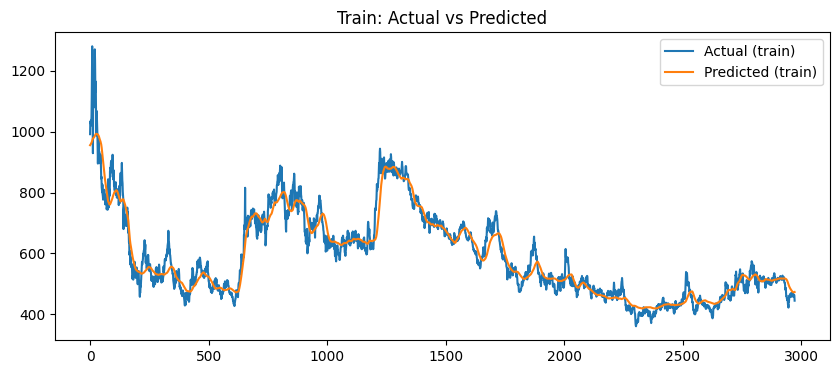


=== Validation set performance ===
Val RMSE: 37.894159
Val R²  : 0.729319
Val MAE : 29.363467


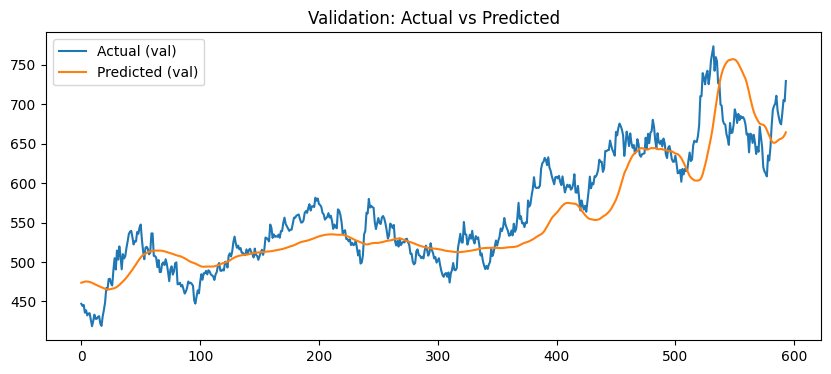


=== Test set performance ===
Test RMSE: 78.669465
Test R²  : 0.764734
Test MAE : 59.085559


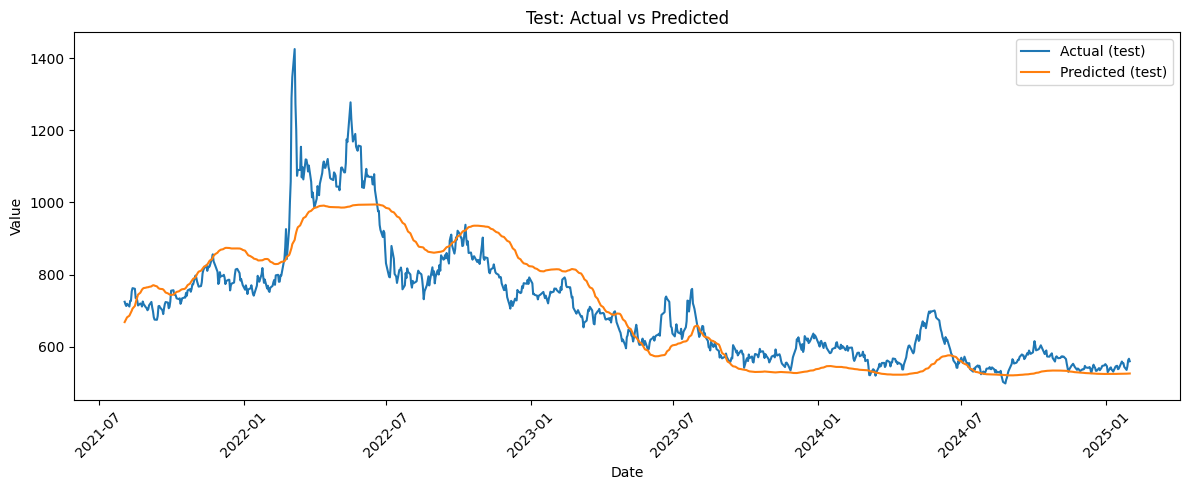

In [ ]:


def cv_cnn_self_attention_rmse(
    X_train: np.ndarray,
    y_train: np.ndarray,
    model_builder,
    encoder_bidirectional: bool = False,
    use_attention: bool = True,
    weight_decay: float = 0.02,
    encoder_units: int = 64,     # -> filters
    decoder_units: int = 128,    # -> dense_units
    dropout: float = 0.2,
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3
) -> float:
    """
    Returns mean CV validation RMSE on ORIGINAL y scale.
    Uses your fold-wise scalers (no leakage).
    """
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    fold_rmses = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        K.clear_session()
        gc.collect()

        # (Optional) make trials more comparable by controlling randomness
        tf.keras.utils.set_random_seed(1234 + fold)

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # scalers (your way)
        x_scaler = fit_x_scaler_3d(X_tr)
        X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
        X_val_s = transform_x_scaler_3d(x_scaler, X_val)

        y_scaler = fit_y_scaler(y_tr)
        y_tr_s = transform_y(y_scaler, y_tr)
        y_val_s = transform_y(y_scaler, y_val)

        model = model_builder(
            seq_length=lookback,
            feature_dim=n_features,
            filters=encoder_units,
            dense_units=decoder_units,
            dropout=dropout,
            kernel_reg=weight_decay,
            encoder_bidirectional=encoder_bidirectional,
            use_attention=use_attention,
        )

        model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss="mean_squared_error"
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=early_stop_patience,
            restore_best_weights=True,
            verbose=0
        )
        reduce_lr = ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        )

        model.fit(
            X_tr_s, y_tr_s,
            validation_data=(X_val_s, y_val_s),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        # --- RMSE in original scale ---
        y_val_pred_scaled = model.predict(X_val_s, verbose=0).reshape(-1)
        y_val_pred = inverse_y(y_scaler, y_val_pred_scaled)
        rmse = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))
        fold_rmses.append(rmse)

        del model

    return float(np.mean(fold_rmses))

def objective(trial):
    weight_decay = trial.suggest_float("weight_decay", 5e-4, 2e-2, log=True)
    encoder_units = trial.suggest_categorical("encoder_units", [32, 64, 128])
    decoder_units = trial.suggest_categorical("decoder_units", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    early_stop_patience = trial.suggest_int("early_stop_patience", 10, 15)
    epochs = trial.suggest_int("epochs", 50, 200)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)

    return cv_cnn_self_attention_rmse(
        X_train=X_train,
        y_train=y_train,
        model_builder=build_cnn_with_self_attention,
        encoder_bidirectional=False,
        use_attention=True,
        weight_decay=weight_decay,
        encoder_units=encoder_units,
        decoder_units=decoder_units,
        dropout=dropout,
        early_stop_patience=early_stop_patience,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate
    )
optuna.logging.set_verbosity(optuna.logging.INFO)

study = optuna.create_study(direction="minimize")

def print_callback(study, trial):
    print(
        f"[Trial {trial.number}] value={trial.value:.4f} params={trial.params}",
        flush=True
    )

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True,      # nice in Colab
    callbacks=[print_callback],  # forces printing every trial
)

print("Best value:", study.best_value)
print("Best params:", study.best_params)

baseline = cv_cnn_self_attention_rmse(
    X_train, y_train, build_cnn_with_self_attention,
    use_attention=True,
    weight_decay=0.02, encoder_units=64, decoder_units=128,
    dropout=0.2, early_stop_patience=10, epochs=100, batch_size=64, learning_rate=1e-3
)
print("Baseline CV RMSE:", baseline)


def plot_best_cnn(
    df_all,  # can be None (then x-axis is just index)
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_builder,                 # e.g. build_cnn_with_self_attention
    encoder_bidirectional: bool = False,
    use_attention: bool = True,
    weight_decay: float = 0.02,
    encoder_units: int = 64,       # -> filters
    decoder_units: int = 128,      # -> dense_units
    dropout: float = 0.2,
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3
):
    """
    Mimics plot_best_gru:
    - trains on the LAST CV fold (train/val)
    - plots Train, Val, Test
    - prints RMSE/R2/MAE for each
    Uses your 3D scalers (fit_x_scaler_3d, fit_y_scaler, etc.)
    """
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    # ---- pick LAST fold ----
    last_train_idx, last_val_idx = None, None
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        last_train_idx, last_val_idx = train_idx, val_idx

    X_tr, X_val = X_train[last_train_idx], X_train[last_val_idx]
    y_tr, y_val = y_train[last_train_idx], y_train[last_val_idx]

    # ---- fold scalers (no leakage) ----
    x_scaler = fit_x_scaler_3d(X_tr)
    X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
    X_val_s = transform_x_scaler_3d(x_scaler, X_val)

    y_scaler = fit_y_scaler(y_tr)
    y_tr_s = transform_y(y_scaler, y_tr)
    y_val_s = transform_y(y_scaler, y_val)

    # ---- build + train model ----
    model = model_builder(
        seq_length=lookback,
        feature_dim=n_features,
        filters=encoder_units,
        dense_units=decoder_units,
        dropout=dropout,
        kernel_reg=weight_decay,
        encoder_bidirectional=encoder_bidirectional,
        use_attention=use_attention,
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="mean_squared_error"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=early_stop_patience,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )

    model.fit(
        X_tr_s, y_tr_s,
        validation_data=(X_val_s, y_val_s),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # ============ TRAIN plot ============
    y_tr_pred_scaled = model.predict(X_tr_s, verbose=0).reshape(-1)
    y_tr_pred = inverse_y(y_scaler, y_tr_pred_scaled)

    train_rmse = float(np.sqrt(mean_squared_error(y_tr, y_tr_pred)))
    train_r2   = float(r2_score(y_tr, y_tr_pred))
    train_mae  = float(mean_absolute_error(y_tr, y_tr_pred))

    print("\n=== Train set performance ===")
    print(f"Train RMSE: {train_rmse:.6f}")
    print(f"Train R²  : {train_r2:.6f}")
    print(f"Train MAE : {train_mae:.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(y_tr, label="Actual (train)")
    plt.plot(y_tr_pred, label="Predicted (train)")
    plt.title("Train: Actual vs Predicted")
    plt.legend()
    plt.show()

    # ============ VAL plot ============
    y_val_pred_scaled = model.predict(X_val_s, verbose=0).reshape(-1)
    y_val_pred = inverse_y(y_scaler, y_val_pred_scaled)

    val_rmse = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))
    val_r2   = float(r2_score(y_val, y_val_pred))
    val_mae  = float(mean_absolute_error(y_val, y_val_pred))

    print("\n=== Validation set performance ===")
    print(f"Val RMSE: {val_rmse:.6f}")
    print(f"Val R²  : {val_r2:.6f}")
    print(f"Val MAE : {val_mae:.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(y_val, label="Actual (val)")
    plt.plot(y_val_pred, label="Predicted (val)")
    plt.title("Validation: Actual vs Predicted")
    plt.legend()
    plt.show()

    # ============ TEST plot ============
    # (To match your CNN pipeline style: scale test using THIS fold’s x_scaler)
    X_test_s = transform_x_scaler_3d(x_scaler, X_test)
    y_test_pred_scaled = model.predict(X_test_s, verbose=0).reshape(-1)
    y_test_pred = inverse_y(y_scaler, y_test_pred_scaled)

    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_test_pred)))
    test_r2   = float(r2_score(y_test, y_test_pred))
    test_mae  = float(mean_absolute_error(y_test, y_test_pred))

    print("\n=== Test set performance ===")
    print(f"Test RMSE: {test_rmse:.6f}")
    print(f"Test R²  : {test_r2:.6f}")
    print(f"Test MAE : {test_mae:.6f}")

    if df_all is not None and hasattr(df_all, "index"):
        test_len = len(X_test)
        test_dates = df_all.index[-test_len:]
        plt.figure(figsize=(12, 5))
        plt.plot(test_dates, y_test, label="Actual (test)")
        plt.plot(test_dates, y_test_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted")
        plt.xlabel("Date")
        plt.ylabel("Value")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.legend()
        plt.show()
    else:
        plt.figure(figsize=(12, 5))
        plt.plot(y_test, label="Actual (test)")
        plt.plot(y_test_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted")
        plt.legend()
        plt.show()

    return model

print("Best value:", study.best_value)
print("Best params:", study.best_params)

bp = study.best_params

best_model = plot_best_cnn(
    df_all=df_all,          # or None if you don’t have it
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    model_builder=build_cnn_with_self_attention,
    encoder_bidirectional=False,
    use_attention=True,
    weight_decay=bp["weight_decay"],
    encoder_units=bp["encoder_units"],
    decoder_units=bp["decoder_units"],
    dropout=bp["dropout"],
    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
)


# CNN with Temporal Attention Pooling

This model takes a different approach to attention than the self-attention variant above. Instead of computing pairwise relationships between all timesteps, we use a simpler mechanism called temporal attention pooling.

The intuition here is straightforward: not all days in the 30-day window matter equally for predicting tomorrow's price. Maybe what happened in the last week matters more than what happened three weeks ago. Temporal attention pooling learns a weight for each timestep and computes a weighted average of the features.

### Architecture
```
Input (30 days, 33 features)
    ↓
[Conv1D → Dropout] × n_conv_layers
    ↓
TemporalAttentionPooling
    ↓
Dense → Dropout → Dense(1)
    ↓
Output (next-day price)
```

**How the custom layer works:** The `TemporalAttentionPooling` layer takes the sequence output from the CNN and learns which timesteps to focus on. It projects each timestep through a small network to get a score, applies softmax to normalize the scores across time, then takes a weighted sum. This replaces the naive global average pooling that would treat all 30 days equally.

**The trade-off:** This is simpler and faster than full self-attention, but it's also less expressive. It can learn "day 28 matters more than day 5," but it can't learn "day 28 matters *because of* what happened on day 5." That limitation showed up in our results — this model performed significantly worse than the self-attention version on the test set.

**Architecture:** Same CNN backbone as before (stacked Conv1D layers with dropout), but the attention pooling replaces the global average pooling step. The hyperparameter search also explores different attention dimensions and the number of convolutional layers.

**Why we included it:** We wanted to test whether a simpler attention mechanism might generalize better by having fewer parameters. It didn't work out that way — the extra expressiveness of self-attention was worth the additional complexity.

### Results

| Dataset | RMSE | R² | MAE |
|---------|------|-----|-----|
| Train | 41.48 | 0.917 | 30.30 |
| Validation | 44.40 | 0.628 | 33.87 |
| Test | 148.49 | 0.162 | 116.76 |


[I 2025-12-18 05:57:20,084] A new study created in memory with name: no-name-a6b78a98-6680-4ce8-b1da-65f0930aad10


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-18 05:59:28,832] Trial 0 finished with value: 105.40588238887464 and parameters: {'weight_decay': 0.001990699667393337, 'filters': 32, 'dense_units': 32, 'dropout': 0.273235229154987, 'kernel_size': 7, 'n_conv_layers': 4, 'attn_units': 128, 'early_stop_patience': 13, 'epochs': 115, 'batch_size': 64, 'learning_rate': 2.621087878265438e-05}. Best is trial 0 with value: 105.40588238887464.
[Trial 0] value=105.4059 params={'weight_decay': 0.001990699667393337, 'filters': 32, 'dense_units': 32, 'dropout': 0.273235229154987, 'kernel_size': 7, 'n_conv_layers': 4, 'attn_units': 128, 'early_stop_patience': 13, 'epochs': 115, 'batch_size': 64, 'learning_rate': 2.621087878265438e-05}
[I 2025-12-18 06:01:58,010] Trial 1 finished with value: 99.77130664212784 and parameters: {'weight_decay': 0.0014689372953975099, 'filters': 128, 'dense_units': 128, 'dropout': 0.10929008254399955, 'kernel_size': 7, 'n_conv_layers': 4, 'attn_units': 16, 'early_stop_patience': 12, 'epochs': 68, 'batch_size

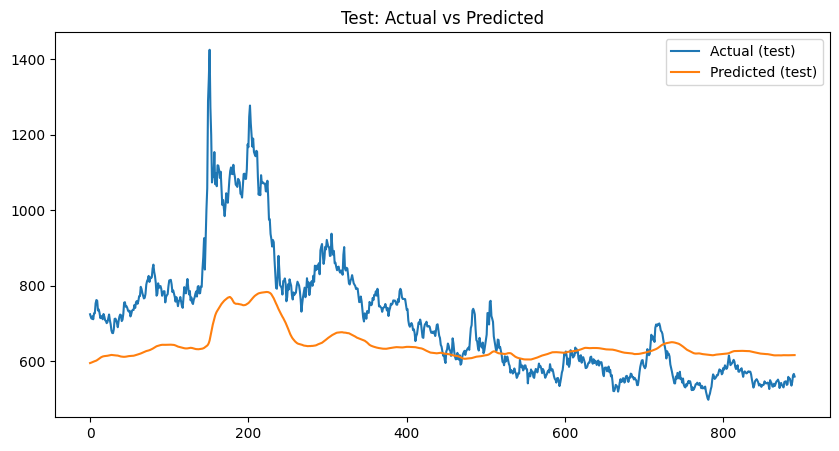


=== Final retrain performance ===
Test RMSE: 180.488847
Test R²  : -0.238362


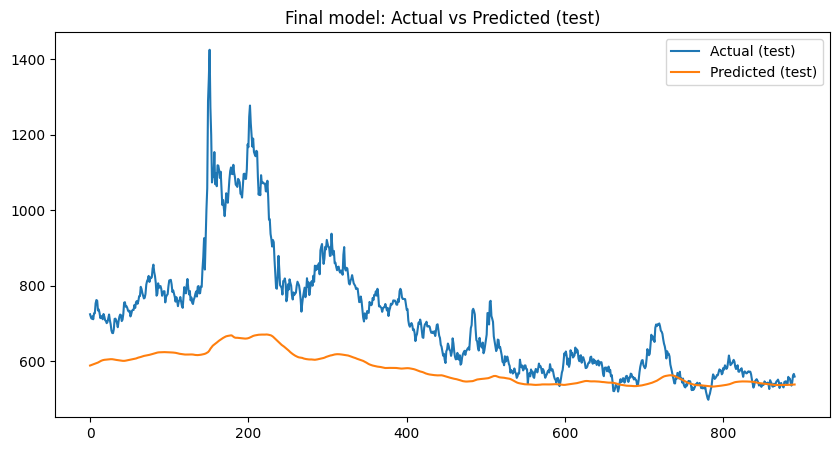

CV metrics: {'rmse': 147.40059608673394, 'r2': 0.17406586511499034}
Final metrics: {'rmse': 180.48884710841915, 'r2': -0.23836217257203884}

=== Train set performance ===
Train RMSE: 41.479225
Train R²  : 0.916837
Train MAE : 30.304428


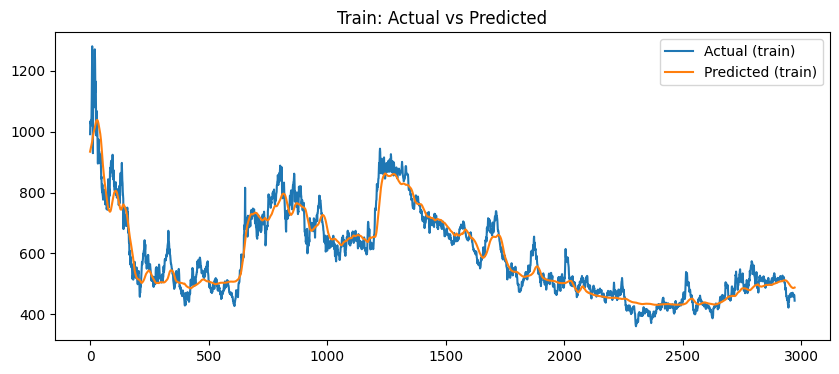


=== Validation set performance ===
Val RMSE: 44.395175
Val R²  : 0.628478
Val MAE : 33.865426


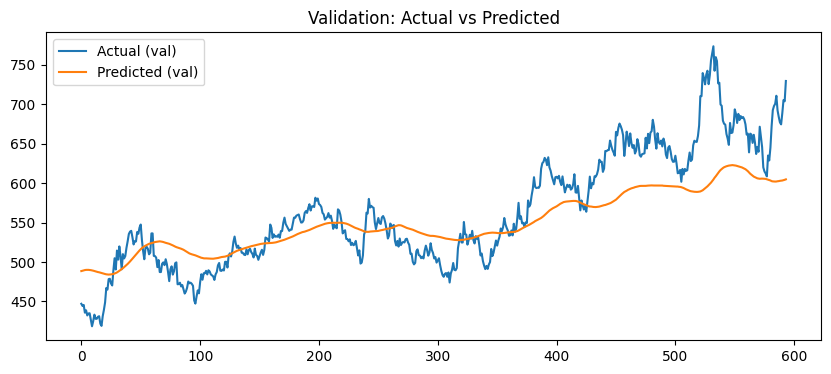


=== Test set performance ===
Test RMSE: 148.494866
Test R²  : 0.161757
Test MAE : 116.761225


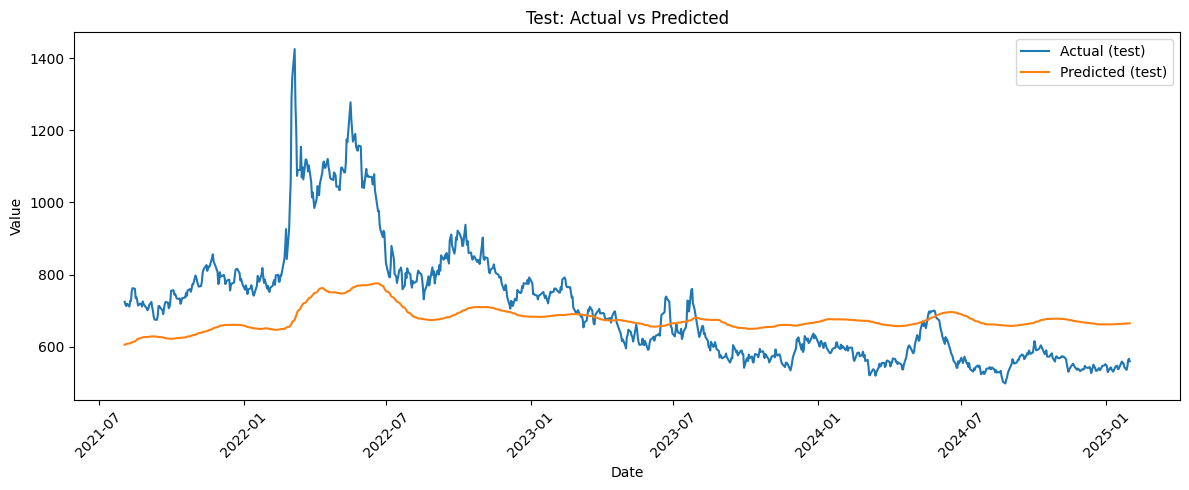

In [ ]:


class TemporalAttentionPooling(layers.Layer):
    def __init__(self, attn_units: int = 64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(attn_units, activation="tanh")
        self.v = layers.Dense(1, activation=None)

    def call(self, x):
        scores = self.v(self.W(x))              # (B, T, 1)
        weights = tf.nn.softmax(scores, axis=1) # (B, T, 1)
        return tf.reduce_sum(weights * x, axis=1)  # (B, C)
def build_cnn_with_attention(
    seq_length: int,
    feature_dim: int,
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 3,
    dropout: float = 0.2,
    kernel_reg: float = 0.02,
    encoder_bidirectional: bool = False,  # unused
    use_attention: bool = True,
    attn_units: int = 64,
    dense_units: int = 128,
    output_activation: str = "linear",
    learning_rate: float = 1e-3
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))
    x = inputs

    for _ in range(n_conv_layers):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(kernel_reg),
        )(x)
        x = layers.Dropout(dropout)(x)

    x = TemporalAttentionPooling(attn_units=attn_units)(x) if use_attention else layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(dense_units, activation="relu",
                     kernel_regularizer=regularizers.l2(kernel_reg))(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(1, activation=output_activation,
                           kernel_regularizer=regularizers.l2(kernel_reg))(x)

    return Model(inputs, outputs)

def cv_cnn_attention_rmse(
    X_train: np.ndarray,
    y_train: np.ndarray,
    model_builder,                # <-- build_cnn_with_attention
    encoder_bidirectional: bool = False,
    use_attention: bool = True,

    # model hyperparams
    weight_decay: float = 0.02,   # -> kernel_reg
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 3,
    attn_units: int = 64,
    dense_units: int = 128,
    dropout: float = 0.2,

    # train hyperparams
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3,

    # seed control
    base_seed: int = 1234
) -> float:
    """
    Returns mean CV validation RMSE on ORIGINAL y scale.
    Fold-wise scalers (no leakage).
    """
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    fold_rmses = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        K.clear_session()
        gc.collect()
        tf.keras.utils.set_random_seed(base_seed + fold)

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # scalers (your existing helpers)
        x_scaler = fit_x_scaler_3d(X_tr)
        X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
        X_val_s = transform_x_scaler_3d(x_scaler, X_val)

        y_scaler = fit_y_scaler(y_tr)
        y_tr_s = transform_y(y_scaler, y_tr)
        y_val_s = transform_y(y_scaler, y_val)

        # build model
        model = model_builder(
            seq_length=lookback,
            feature_dim=n_features,
            filters=filters,
            kernel_size=kernel_size,
            n_conv_layers=n_conv_layers,
            dropout=dropout,
            kernel_reg=weight_decay,
            encoder_bidirectional=encoder_bidirectional,
            use_attention=use_attention,
            attn_units=attn_units,
            dense_units=dense_units,
        )

        model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss="mean_squared_error"
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=early_stop_patience,
            restore_best_weights=True,
            verbose=0
        )
        reduce_lr = ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        )

        model.fit(
            X_tr_s, y_tr_s,
            validation_data=(X_val_s, y_val_s),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        # RMSE on original scale
        y_val_pred_scaled = model.predict(X_val_s, verbose=0).reshape(-1)
        y_val_pred = inverse_y(y_scaler, y_val_pred_scaled)
        rmse = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))
        fold_rmses.append(rmse)

        del model

    return float(np.mean(fold_rmses))
def objective(trial):
    # model hyperparams
    weight_decay  = trial.suggest_float("weight_decay", 5e-4, 2e-2, log=True)
    filters       = trial.suggest_categorical("filters", [32, 64, 128])
    dense_units   = trial.suggest_categorical("dense_units", [32, 64, 128])
    dropout       = trial.suggest_float("dropout", 0.10, 0.30)

    kernel_size   = trial.suggest_categorical("kernel_size", [2, 3, 5, 7])
    n_conv_layers = trial.suggest_int("n_conv_layers", 1, 4)
    attn_units    = trial.suggest_categorical("attn_units", [16, 32, 64, 128])

    # training hyperparams
    early_stop_patience = trial.suggest_int("early_stop_patience", 10, 15)
    epochs              = trial.suggest_int("epochs", 50, 200)
    batch_size          = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate       = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)

    return cv_cnn_attention_rmse(
        X_train=X_train,
        y_train=y_train,
        model_builder=build_cnn_with_attention,
        encoder_bidirectional=False,
        use_attention=True,

        weight_decay=weight_decay,
        filters=filters,
        kernel_size=kernel_size,
        n_conv_layers=n_conv_layers,
        attn_units=attn_units,
        dense_units=dense_units,
        dropout=dropout,

        early_stop_patience=early_stop_patience,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        base_seed=1234
    )

optuna.logging.set_verbosity(optuna.logging.INFO)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

def print_callback(study, trial):
    print(f"[Trial {trial.number}] value={trial.value:.4f} params={trial.params}", flush=True)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True,
    callbacks=[print_callback],
)

print("Best value (CV RMSE):", study.best_value)
print("Best params:", study.best_params)
baseline = cv_cnn_attention_rmse(
    X_train, y_train, build_cnn_with_attention,
    use_attention=True,
    weight_decay=0.02,
    filters=64, kernel_size=3, n_conv_layers=3,
    attn_units=64,
    dense_units=128,
    dropout=0.2,
    early_stop_patience=10,
    epochs=100,
    batch_size=64,
    learning_rate=1e-3
)
print("Baseline CV RMSE:", baseline)
bp = study.best_params
T, F = X_train.shape[1], X_train.shape[2]

def best_origin_attn(encoder_bidirectional=False, use_attention=True):
    return build_cnn_with_attention(
        seq_length=T, feature_dim=F,
        filters=bp["filters"],
        kernel_size=bp["kernel_size"],
        n_conv_layers=bp["n_conv_layers"],
        dropout=bp["dropout"],
        kernel_reg=bp["weight_decay"],
        attn_units=bp["attn_units"],
        dense_units=bp["dense_units"],
        encoder_bidirectional=encoder_bidirectional,
        use_attention=use_attention,
    )

cv_model, cv_xs, cv_ys, cv_pred, cv_metrics = cv_train_timeseries_model(
    X_train, y_train, X_test, y_test,
    model_origin=best_origin_attn,
    use_attention=True,
    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
    plot_test=True
)

final_model, xs, ys, yhat, metrics = train_final_model_and_eval(
    X_train, y_train, X_test, y_test,
    model_origin=best_origin_attn,
    use_attention=True,
    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
    plot_test=True
)

print("CV metrics:", cv_metrics)
print("Final metrics:", metrics)


def plot_best_cnn_attention(
    df_all,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_builder,                 # build_cnn_with_attention
    encoder_bidirectional: bool = False,
    use_attention: bool = True,

    # model hyperparams
    weight_decay: float = 0.02,
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 3,
    attn_units: int = 64,
    dense_units: int = 128,
    dropout: float = 0.2,

    # training hyperparams
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3,

    base_seed: int = 1234
):
    """
    Trains on the LAST CV fold (train/val), then plots:
    - Train: Actual vs Predicted
    - Val  : Actual vs Predicted
    - Test : Actual vs Predicted
    Metrics printed on ORIGINAL y scale.
    """
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    # ---- pick LAST fold ----
    last_train_idx, last_val_idx = None, None
    for _, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        last_train_idx, last_val_idx = train_idx, val_idx

    X_tr, X_val = X_train[last_train_idx], X_train[last_val_idx]
    y_tr, y_val = y_train[last_train_idx], y_train[last_val_idx]

    # ---- fold scalers (no leakage) ----
    x_scaler = fit_x_scaler_3d(X_tr)
    X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
    X_val_s = transform_x_scaler_3d(x_scaler, X_val)

    y_scaler = fit_y_scaler(y_tr)
    y_tr_s = transform_y(y_scaler, y_tr)
    y_val_s = transform_y(y_scaler, y_val)

    # ---- build + train model ----
    tf.keras.utils.set_random_seed(base_seed)

    model = model_builder(
        seq_length=lookback,
        feature_dim=n_features,
        filters=filters,
        kernel_size=kernel_size,
        n_conv_layers=n_conv_layers,
        dropout=dropout,
        kernel_reg=weight_decay,
        encoder_bidirectional=encoder_bidirectional,
        use_attention=use_attention,
        attn_units=attn_units,
        dense_units=dense_units,
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="mean_squared_error"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=early_stop_patience,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )

    model.fit(
        X_tr_s, y_tr_s,
        validation_data=(X_val_s, y_val_s),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # ================= TRAIN =================
    y_tr_pred_scaled = model.predict(X_tr_s, verbose=0).reshape(-1)
    y_tr_pred = inverse_y(y_scaler, y_tr_pred_scaled)

    train_rmse = float(np.sqrt(mean_squared_error(y_tr, y_tr_pred)))
    train_r2   = float(r2_score(y_tr, y_tr_pred))
    train_mae  = float(mean_absolute_error(y_tr, y_tr_pred))

    print("\n=== Train set performance ===")
    print(f"Train RMSE: {train_rmse:.6f}")
    print(f"Train R²  : {train_r2:.6f}")
    print(f"Train MAE : {train_mae:.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(y_tr, label="Actual (train)")
    plt.plot(y_tr_pred, label="Predicted (train)")
    plt.title("Train: Actual vs Predicted")
    plt.legend()
    plt.show()

    # ================= VAL =================
    y_val_pred_scaled = model.predict(X_val_s, verbose=0).reshape(-1)
    y_val_pred = inverse_y(y_scaler, y_val_pred_scaled)

    val_rmse = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))
    val_r2   = float(r2_score(y_val, y_val_pred))
    val_mae  = float(mean_absolute_error(y_val, y_val_pred))

    print("\n=== Validation set performance ===")
    print(f"Val RMSE: {val_rmse:.6f}")
    print(f"Val R²  : {val_r2:.6f}")
    print(f"Val MAE : {val_mae:.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(y_val, label="Actual (val)")
    plt.plot(y_val_pred, label="Predicted (val)")
    plt.title("Validation: Actual vs Predicted")
    plt.legend()
    plt.show()

    # ================= TEST =================
    X_test_s = transform_x_scaler_3d(x_scaler, X_test)
    y_test_pred_scaled = model.predict(X_test_s, verbose=0).reshape(-1)
    y_test_pred = inverse_y(y_scaler, y_test_pred_scaled)

    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_test_pred)))
    test_r2   = float(r2_score(y_test, y_test_pred))
    test_mae  = float(mean_absolute_error(y_test, y_test_pred))

    print("\n=== Test set performance ===")
    print(f"Test RMSE: {test_rmse:.6f}")
    print(f"Test R²  : {test_r2:.6f}")
    print(f"Test MAE : {test_mae:.6f}")

    if df_all is not None and hasattr(df_all, "index"):
        test_dates = df_all.index[-len(X_test):]
        plt.figure(figsize=(12, 5))
        plt.plot(test_dates, y_test, label="Actual (test)")
        plt.plot(test_dates, y_test_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted")
        plt.xlabel("Date")
        plt.ylabel("Value")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.legend()
        plt.show()
    else:
        plt.figure(figsize=(12, 5))
        plt.plot(y_test, label="Actual (test)")
        plt.plot(y_test_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted")
        plt.legend()
        plt.show()

    return model

bp = study.best_params

best_model = plot_best_cnn_attention(
    df_all=df_all,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    model_builder=build_cnn_with_attention,
    encoder_bidirectional=False,
    use_attention=True,

    weight_decay=bp["weight_decay"],
    filters=bp["filters"],
    kernel_size=bp["kernel_size"],
    n_conv_layers=bp["n_conv_layers"],
    attn_units=bp["attn_units"],
    dense_units=bp["dense_units"],
    dropout=bp["dropout"],

    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
)


# RCNN with Self-Attention

This is where we tested whether adding recurrent layers on top of the CNN would help. The thinking was that GRU (or LSTM) layers are specifically designed to model sequential dependencies — they maintain a hidden state that carries information forward through time. Maybe this would capture patterns that the CNN misses.

### Architecture
```
Input (30 days, 33 features)
    ↓
[Conv1D → Dropout] × n_conv_layers
    ↓
[GRU] × n_rnn_layers
    ↓
SeqSelfAttention
    ↓
GlobalAveragePooling1D
    ↓
Dense → Dropout → Dense(1)
    ↓
Output (next-day price)
```

**The architecture:** We start with the same CNN stack to extract local features from the 30-day window. Then we pass the output through one or more GRU layers, which process the sequence step by step and build up a representation of the temporal dynamics. Finally, we apply self-attention to let the model focus on the most relevant parts of the GRU output, followed by pooling and a dense layer for the prediction.

**Why this didn't work as well as we hoped:** On paper, this should be a powerful combination — local patterns from CNN, sequential memory from GRU, global context from self-attention. But in practice, the model has a lot more parameters than the CNN-only version, and it ended up overfitting. The training metrics looked fine, but performance degraded significantly on the test set.

Looking back, this makes sense for a 30-day window. The GRU is designed for cases where you need to remember things over long sequences — hundreds or thousands of timesteps. For just 30 days, the CNN with a reasonable kernel size can already "see" most of the relevant context, and the self-attention can handle the rest. The GRU added complexity without adding much useful capacity.

**The hyperparameter search** explores more dimensions here: not just filter sizes and learning rates, but also the number of GRU units and layers. More knobs to turn, but also more opportunities to overfit.

### Results

| Dataset | RMSE | R² | MAE |
|---------|------|-----|-----|
| Train | 39.73 | 0.924 | 27.91 |
| Validation | 65.97 | 0.180 | 49.28 |
| Test | 155.01 | 0.087 | 115.93 |


[I 2025-12-18 12:17:38,430] A new study created in memory with name: no-name-86fee5b1-502a-4a8c-b583-2895ba686658


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-18 12:18:49,833] Trial 0 finished with value: 79.83697570584675 and parameters: {'weight_decay': 0.001990699667393337, 'filters': 32, 'rnn_units': 32, 'dense_units': 32, 'kernel_size': 3, 'n_conv_layers': 1, 'dropout': 0.13668090197068677, 'early_stop_patience': 11, 'epochs': 129, 'batch_size': 32, 'learning_rate': 0.000684792009557478}. Best is trial 0 with value: 79.83697570584675.
[Trial 0] value=79.8370 params={'weight_decay': 0.001990699667393337, 'filters': 32, 'rnn_units': 32, 'dense_units': 32, 'kernel_size': 3, 'n_conv_layers': 1, 'dropout': 0.13668090197068677, 'early_stop_patience': 11, 'epochs': 129, 'batch_size': 32, 'learning_rate': 0.000684792009557478}
[I 2025-12-18 12:20:32,049] Trial 1 finished with value: 79.59447684474824 and parameters: {'weight_decay': 0.0008364645453054503, 'filters': 128, 'rnn_units': 32, 'dense_units': 128, 'kernel_size': 7, 'n_conv_layers': 3, 'dropout': 0.16092275383467414, 'early_stop_patience': 10, 'epochs': 153, 'batch_size': 32

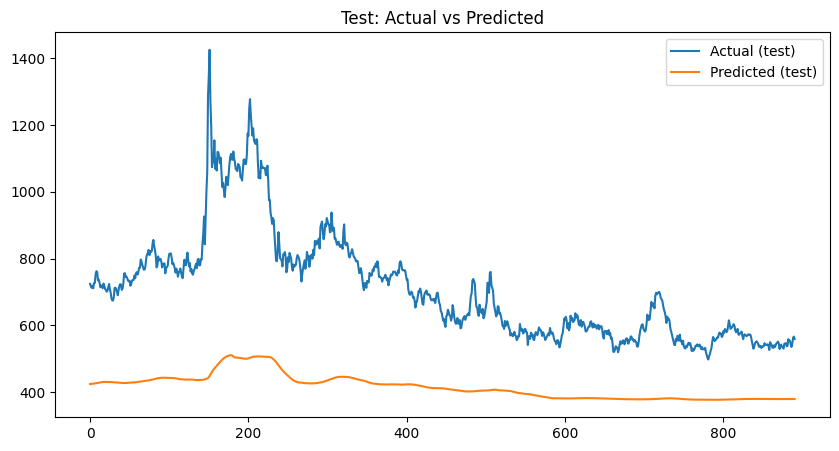


=== Final retrain performance ===
Test RMSE: 188.796336
Test R²  : -0.354984


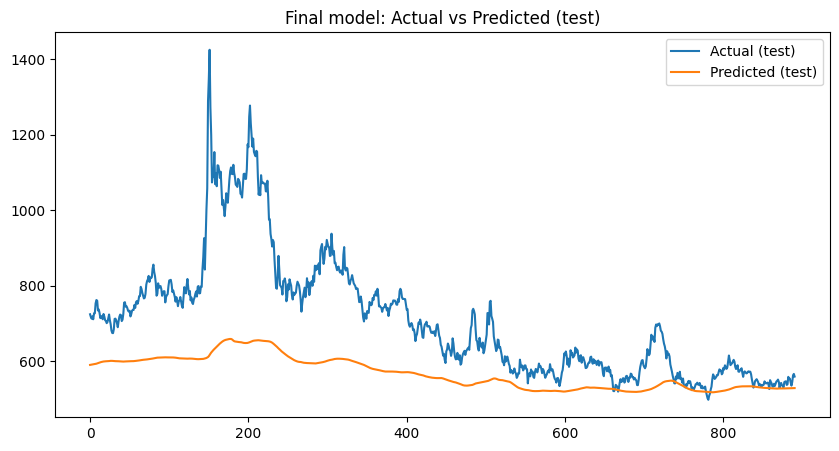

CV metrics: {'rmse': 320.711587692874, 'r2': -2.90999533575393}
Final metrics: {'rmse': 188.7963363586851, 'r2': -0.3549836682240475}

=== Train set performance ===
Train RMSE: 70.007622
Train R²  : 0.763104
Train MAE : 50.469607


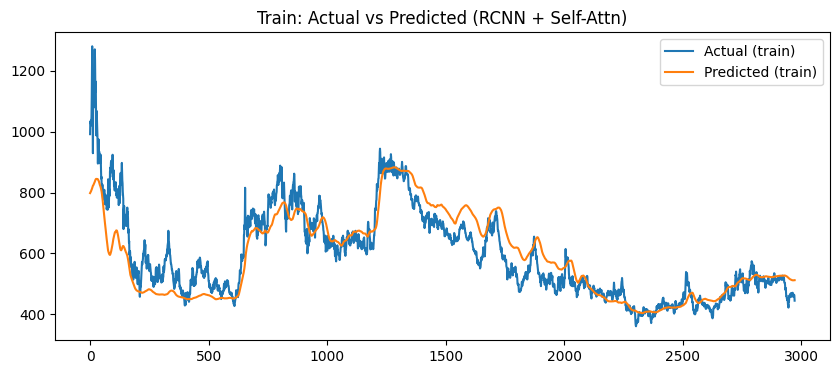


=== Validation set performance ===
Val RMSE: 56.293246
Val R²  : 0.402655
Val MAE : 43.331687


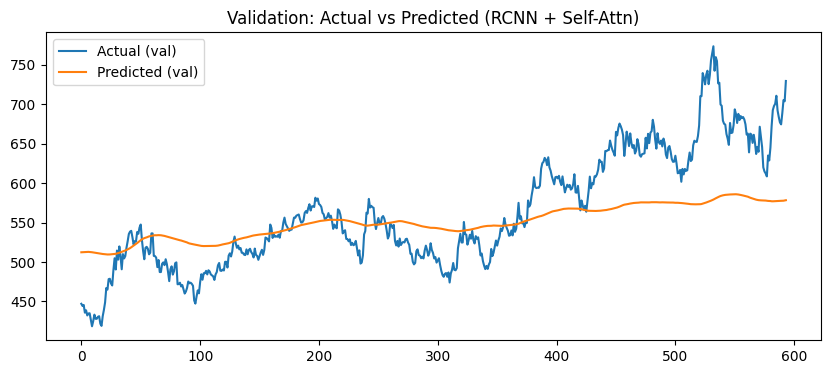


=== Test set performance ===
Test RMSE: 189.803027
Test R²  : -0.369472
Test MAE : 135.368107


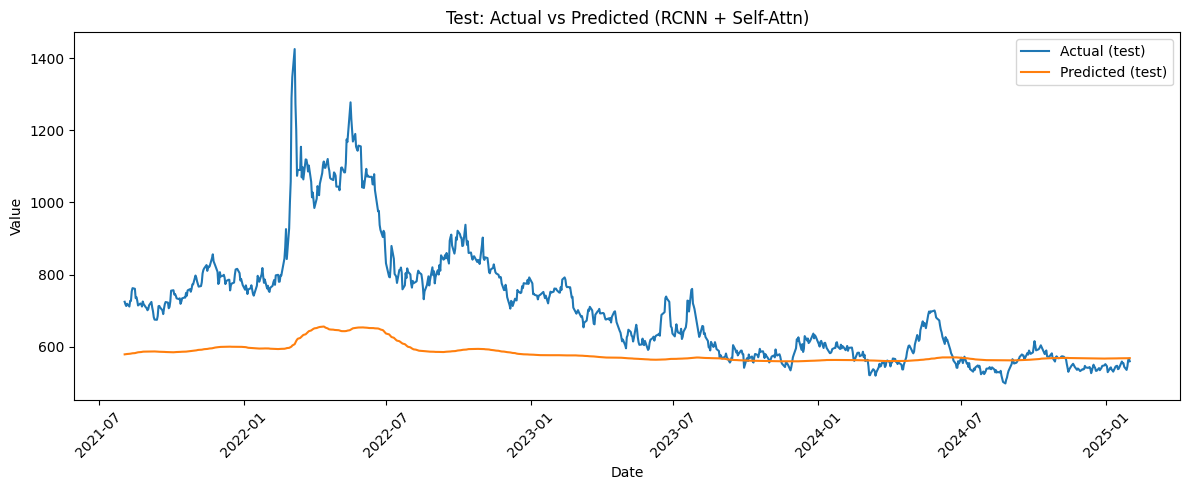

In [ ]:
from tensorflow.keras import layers, regularizers, Input, Model
# if you used this in CNN self-attention already, keep the same import:
from keras_self_attention import SeqSelfAttention
import gc
import numpy as np
import optuna
import tensorflow as tf
from tensorflow.keras import backend as K

def build_rcnn_with_self_attention(
    seq_length: int,
    feature_dim: int,

    # CNN front-end
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,
    dropout: float = 0.2,
    kernel_reg: float = 0.02,

    # RNN back-end
    rnn_units: int = 64,
    encoder_bidirectional: bool = False,

    # attention
    use_attention: bool = True,
    attention_activation: str = "sigmoid",

    # head
    dense_units: int = 128,
    output_activation: str = "linear",

    # kept for signature parity
    learning_rate: float = 1e-3
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))
    x = inputs

    # Conv1D stack -> (B, T, C)
    for _ in range(n_conv_layers):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(kernel_reg),
        )(x)
        x = layers.Dropout(dropout)(x)

    # If using attention, we need sequences from GRU
    return_seq = True if use_attention else False

    gru = layers.GRU(
        rnn_units,
        return_sequences=return_seq,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )
    if encoder_bidirectional:
        x = layers.Bidirectional(gru)(x)
    else:
        x = gru(x)

    # Self-attention over time, then pool
    if use_attention:
        x = SeqSelfAttention(attention_activation=attention_activation)(x)
        x = layers.LayerNormalization()(x)
        x = layers.GlobalAveragePooling1D()(x)
    # else: x is already (B, rnn_units) (or 2*rnn_units if bidir)

    # Dense head
    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        1,
        activation=output_activation,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)

    return Model(inputs, outputs)


def cv_rcnn_self_attention_rmse(
    X_train: np.ndarray,
    y_train: np.ndarray,
    model_builder,

    # arch hyperparams
    weight_decay: float = 0.02,
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,
    rnn_units: int = 64,
    dense_units: int = 128,
    dropout: float = 0.2,
    attention_activation: str = "sigmoid",

    # toggles
    encoder_bidirectional: bool = False,
    use_attention: bool = True,

    # train hyperparams
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3,

    base_seed: int = 1234
) -> float:
    """
    Mean CV validation RMSE on ORIGINAL y scale.
    """
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    fold_rmses = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        K.clear_session()
        gc.collect()
        tf.keras.utils.set_random_seed(base_seed + fold)

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        x_scaler = fit_x_scaler_3d(X_tr)
        X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
        X_val_s = transform_x_scaler_3d(x_scaler, X_val)

        y_scaler = fit_y_scaler(y_tr)
        y_tr_s = transform_y(y_scaler, y_tr)

        model = model_builder(
            seq_length=lookback,
            feature_dim=n_features,
            filters=filters,
            kernel_size=kernel_size,
            n_conv_layers=n_conv_layers,
            dropout=dropout,
            kernel_reg=weight_decay,
            rnn_units=rnn_units,
            dense_units=dense_units,
            encoder_bidirectional=encoder_bidirectional,
            use_attention=use_attention,
            attention_activation=attention_activation,
        )

        model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss="mean_squared_error"
        )

        early_stop = EarlyStopping(monitor="val_loss", patience=early_stop_patience,
                                   restore_best_weights=True, verbose=0)
        reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                                      min_lr=1e-6, verbose=0)

        model.fit(
            X_tr_s, y_tr_s,
            validation_data=(X_val_s, transform_y(y_scaler, y_val)),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        y_val_pred_scaled = model.predict(X_val_s, verbose=0).reshape(-1)
        y_val_pred = inverse_y(y_scaler, y_val_pred_scaled)
        fold_rmses.append(float(np.sqrt(mean_squared_error(y_val, y_val_pred))))

        del model

    return float(np.mean(fold_rmses))
def objective(trial):
    weight_decay  = trial.suggest_float("weight_decay", 5e-4, 2e-2, log=True)
    filters       = trial.suggest_categorical("filters", [32, 64, 128])
    rnn_units     = trial.suggest_categorical("rnn_units", [32, 64, 128])
    dense_units   = trial.suggest_categorical("dense_units", [32, 64, 128])

    kernel_size   = trial.suggest_categorical("kernel_size", [2, 3, 5, 7])
    n_conv_layers = trial.suggest_int("n_conv_layers", 1, 3)
    dropout       = trial.suggest_float("dropout", 0.10, 0.30)

    early_stop_patience = trial.suggest_int("early_stop_patience", 10, 15)
    epochs              = trial.suggest_int("epochs", 50, 200)
    batch_size          = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate       = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)

    return cv_rcnn_self_attention_rmse(
        X_train=X_train,
        y_train=y_train,
        model_builder=build_rcnn_with_self_attention,

        weight_decay=weight_decay,
        filters=filters,
        kernel_size=kernel_size,
        n_conv_layers=n_conv_layers,
        rnn_units=rnn_units,
        dense_units=dense_units,
        dropout=dropout,

        encoder_bidirectional=False,
        use_attention=True,

        early_stop_patience=early_stop_patience,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
    )

optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))

def print_callback(study, trial):
    print(f"[Trial {trial.number}] value={trial.value:.4f} params={trial.params}", flush=True)

study.optimize(objective, n_trials=50, show_progress_bar=True, callbacks=[print_callback])

print("Best value (CV RMSE):", study.best_value)
print("Best params:", study.best_params)

bp = study.best_params
T, F = X_train.shape[1], X_train.shape[2]

def best_origin_rcnn_self_attn(encoder_bidirectional=False, use_attention=True):
    return build_rcnn_with_self_attention(
        seq_length=T, feature_dim=F,
        filters=bp["filters"],
        kernel_size=bp["kernel_size"],
        n_conv_layers=bp["n_conv_layers"],
        dropout=bp["dropout"],
        kernel_reg=bp["weight_decay"],
        rnn_units=bp["rnn_units"],
        dense_units=bp["dense_units"],
        encoder_bidirectional=encoder_bidirectional,
        use_attention=use_attention,
    )

# Evaluate with your existing functions (unchanged)
cv_model, cv_xs, cv_ys, cv_pred, cv_metrics = cv_train_timeseries_model(
    X_train, y_train, X_test, y_test,
    model_origin=best_origin_rcnn_self_attn,
    encoder_bidirectional=False,
    use_attention=True,
    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
    plot_test=True
)

final_model, xs, ys, yhat, metrics = train_final_model_and_eval(
    X_train, y_train, X_test, y_test,
    model_origin=best_origin_rcnn_self_attn,
    encoder_bidirectional=False,
    use_attention=True,
    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
    plot_test=True
)

print("CV metrics:", cv_metrics)
print("Final metrics:", metrics)


def plot_best_rcnn_self_attention(
    df_all,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_builder,                 # build_rcnn_with_self_attention
    encoder_bidirectional: bool = False,
    use_attention: bool = True,

    # model hyperparams
    weight_decay: float = 0.02,
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,
    rnn_units: int = 64,
    dense_units: int = 128,
    dropout: float = 0.2,
    attention_activation: str = "sigmoid",

    # training hyperparams
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3,

    base_seed: int = 1234
):
    """
    Trains on the LAST CV fold (train/val), then plots:
    - Train: Actual vs Predicted
    - Val  : Actual vs Predicted
    - Test : Actual vs Predicted
    Metrics printed on ORIGINAL y scale.
    """
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    # ---- pick LAST fold ----
    last_train_idx, last_val_idx = None, None
    for _, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        last_train_idx, last_val_idx = train_idx, val_idx

    X_tr, X_val = X_train[last_train_idx], X_train[last_val_idx]
    y_tr, y_val = y_train[last_train_idx], y_train[last_val_idx]

    # ---- fold scalers (no leakage) ----
    x_scaler = fit_x_scaler_3d(X_tr)
    X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
    X_val_s = transform_x_scaler_3d(x_scaler, X_val)

    y_scaler = fit_y_scaler(y_tr)
    y_tr_s = transform_y(y_scaler, y_tr)
    y_val_s = transform_y(y_scaler, y_val)

    # ---- build + train model ----
    tf.keras.utils.set_random_seed(base_seed)

    model = model_builder(
        seq_length=lookback,
        feature_dim=n_features,
        filters=filters,
        kernel_size=kernel_size,
        n_conv_layers=n_conv_layers,
        dropout=dropout,
        kernel_reg=weight_decay,
        rnn_units=rnn_units,
        encoder_bidirectional=encoder_bidirectional,
        use_attention=use_attention,
        attention_activation=attention_activation,
        dense_units=dense_units,
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="mean_squared_error"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=early_stop_patience,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )

    model.fit(
        X_tr_s, y_tr_s,
        validation_data=(X_val_s, y_val_s),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # ================= TRAIN =================
    y_tr_pred_scaled = model.predict(X_tr_s, verbose=0).reshape(-1)
    y_tr_pred = inverse_y(y_scaler, y_tr_pred_scaled)

    train_rmse = float(np.sqrt(mean_squared_error(y_tr, y_tr_pred)))
    train_r2   = float(r2_score(y_tr, y_tr_pred))
    train_mae  = float(mean_absolute_error(y_tr, y_tr_pred))

    print("\n=== Train set performance ===")
    print(f"Train RMSE: {train_rmse:.6f}")
    print(f"Train R²  : {train_r2:.6f}")
    print(f"Train MAE : {train_mae:.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(y_tr, label="Actual (train)")
    plt.plot(y_tr_pred, label="Predicted (train)")
    plt.title("Train: Actual vs Predicted (RCNN + Self-Attn)")
    plt.legend()
    plt.show()

    # ================= VAL =================
    y_val_pred_scaled = model.predict(X_val_s, verbose=0).reshape(-1)
    y_val_pred = inverse_y(y_scaler, y_val_pred_scaled)

    val_rmse = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))
    val_r2   = float(r2_score(y_val, y_val_pred))
    val_mae  = float(mean_absolute_error(y_val, y_val_pred))

    print("\n=== Validation set performance ===")
    print(f"Val RMSE: {val_rmse:.6f}")
    print(f"Val R²  : {val_r2:.6f}")
    print(f"Val MAE : {val_mae:.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(y_val, label="Actual (val)")
    plt.plot(y_val_pred, label="Predicted (val)")
    plt.title("Validation: Actual vs Predicted (RCNN + Self-Attn)")
    plt.legend()
    plt.show()

    # ================= TEST =================
    X_test_s = transform_x_scaler_3d(x_scaler, X_test)
    y_test_pred_scaled = model.predict(X_test_s, verbose=0).reshape(-1)
    y_test_pred = inverse_y(y_scaler, y_test_pred_scaled)

    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_test_pred)))
    test_r2   = float(r2_score(y_test, y_test_pred))
    test_mae  = float(mean_absolute_error(y_test, y_test_pred))

    print("\n=== Test set performance ===")
    print(f"Test RMSE: {test_rmse:.6f}")
    print(f"Test R²  : {test_r2:.6f}")
    print(f"Test MAE : {test_mae:.6f}")

    if df_all is not None and hasattr(df_all, "index"):
        test_dates = df_all.index[-len(X_test):]
        plt.figure(figsize=(12, 5))
        plt.plot(test_dates, y_test, label="Actual (test)")
        plt.plot(test_dates, y_test_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted (RCNN + Self-Attn)")
        plt.xlabel("Date")
        plt.ylabel("Value")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.legend()
        plt.show()
    else:
        plt.figure(figsize=(12, 5))
        plt.plot(y_test, label="Actual (test)")
        plt.plot(y_test_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted (RCNN + Self-Attn)")
        plt.legend()
        plt.show()

    return model
bp = study.best_params

best_model = plot_best_rcnn_self_attention(
    df_all=df_all,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    model_builder=build_rcnn_with_self_attention,
    encoder_bidirectional=False,
    use_attention=True,

    weight_decay=bp["weight_decay"],
    filters=bp["filters"],
    kernel_size=bp["kernel_size"],
    n_conv_layers=bp["n_conv_layers"],
    rnn_units=bp["rnn_units"],
    dense_units=bp["dense_units"],
    dropout=bp["dropout"],

    # if you’re not tuning this, keep it fixed:
    attention_activation="sigmoid",

    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
)


[I 2025-12-19 00:07:56,392] A new study created in memory with name: no-name-120a03d9-2169-4b89-bdb6-f4098a599c53


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-19 00:09:35,927] Trial 0 finished with value: 91.31454993585103 and parameters: {'weight_decay': 0.001990699667393337, 'filters': 32, 'rnn_units': 32, 'dense_units': 32, 'dropout': 0.10411689885916049, 'kernel_size': 2, 'n_conv_layers': 1, 'attention_activation': 'tanh', 'early_stop_patience': 12, 'epochs': 93, 'batch_size': 32, 'learning_rate': 7.52374288453485e-05}. Best is trial 0 with value: 91.31454993585103.
[Trial 0] value=91.3145 params={'weight_decay': 0.001990699667393337, 'filters': 32, 'rnn_units': 32, 'dense_units': 32, 'dropout': 0.10411689885916049, 'kernel_size': 2, 'n_conv_layers': 1, 'attention_activation': 'tanh', 'early_stop_patience': 12, 'epochs': 93, 'batch_size': 32, 'learning_rate': 7.52374288453485e-05}
[I 2025-12-19 00:11:17,039] Trial 1 finished with value: 77.741509726476 and parameters: {'weight_decay': 0.001931539775428364, 'filters': 64, 'rnn_units': 64, 'dense_units': 32, 'dropout': 0.28977710745066665, 'kernel_size': 2, 'n_conv_layers': 3, '

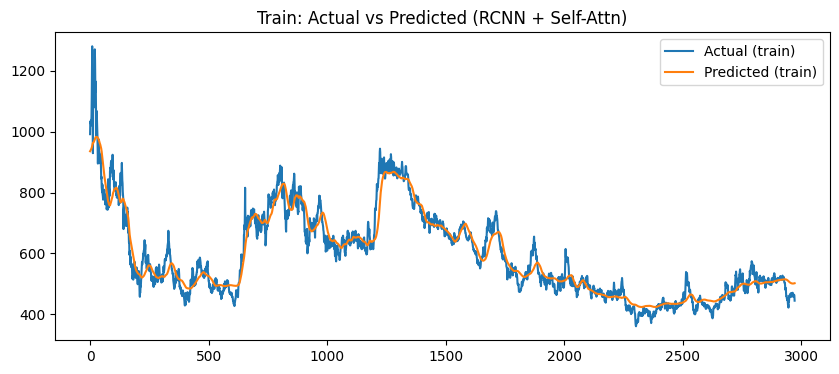


=== Validation set performance ===
Val RMSE: 65.967801
Val R²  : 0.179693
Val MAE : 49.284174


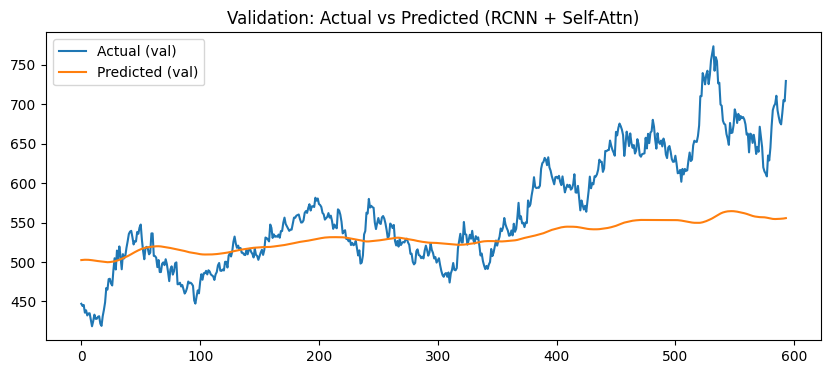


=== Test set performance ===
Test RMSE: 155.010743
Test R²  : 0.086580
Test MAE : 115.928580


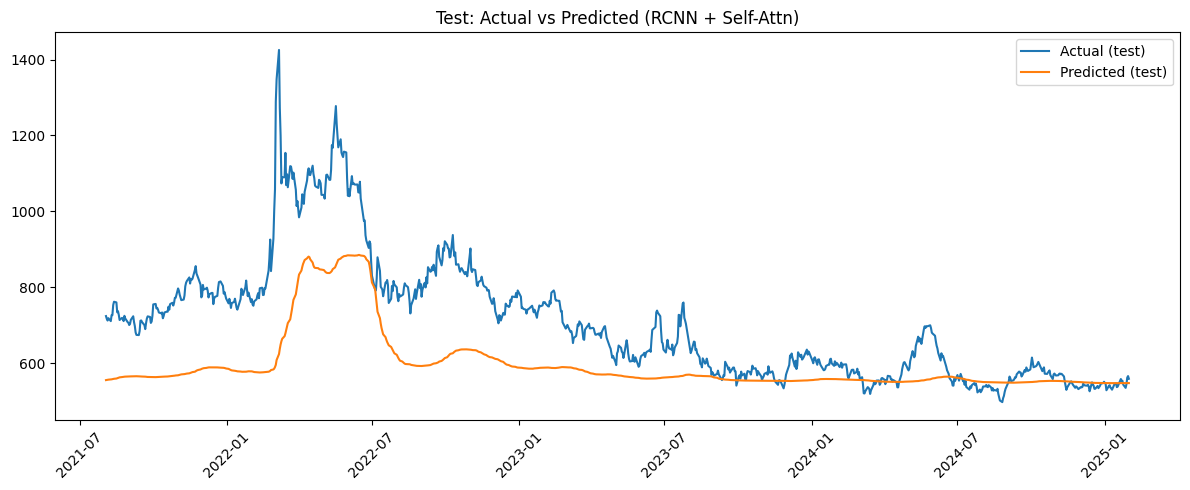

In [ ]:


def build_rcnn_with_self_attention(
    seq_length: int,
    feature_dim: int,

    # CNN front-end
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,
    dropout: float = 0.2,
    kernel_reg: float = 0.02,

    # RNN back-end
    rnn_units: int = 64,
    encoder_bidirectional: bool = False,

    # attention
    use_attention: bool = True,
    attention_activation: str = "sigmoid",

    # head
    dense_units: int = 128,
    output_activation: str = "linear",

    # kept for signature parity
    learning_rate: float = 1e-3
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))
    x = inputs

    # Conv1D stack -> (B, T, C)
    for _ in range(n_conv_layers):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(kernel_reg),
        )(x)
        x = layers.Dropout(dropout)(x)

    # If using attention, we need sequences from GRU
    return_seq = True if use_attention else False

    gru = layers.GRU(
        rnn_units,
        return_sequences=return_seq,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )
    if encoder_bidirectional:
        x = layers.Bidirectional(gru)(x)
    else:
        x = gru(x)

    # Self-attention over time, then pool
    if use_attention:
        x = SeqSelfAttention(attention_activation=attention_activation)(x)
        x = layers.LayerNormalization()(x)
        x = layers.GlobalAveragePooling1D()(x)
    # else: x is already (B, rnn_units) (or 2*rnn_units if bidir)

    # Dense head
    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        1,
        activation=output_activation,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)

    return Model(inputs, outputs)

def cv_rcnn_self_attention_rmse(
    X_train: np.ndarray,
    y_train: np.ndarray,
    model_builder,                 # build_rcnn_with_self_attention
    encoder_bidirectional: bool = False,
    use_attention: bool = True,

    # model hyperparams
    weight_decay: float = 0.02,    # -> kernel_reg
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,
    rnn_units: int = 64,
    dense_units: int = 128,
    dropout: float = 0.2,
    attention_activation: str = "sigmoid",

    # training hyperparams
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3,

    base_seed: int = 1234
) -> float:
    """
    Returns mean CV validation RMSE on ORIGINAL y scale.
    Uses fold-wise scalers (no leakage).
    """
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    fold_rmses = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        K.clear_session()
        gc.collect()
        tf.keras.utils.set_random_seed(base_seed + fold)

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # scalers (your existing helpers)
        x_scaler = fit_x_scaler_3d(X_tr)
        X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
        X_val_s = transform_x_scaler_3d(x_scaler, X_val)

        y_scaler = fit_y_scaler(y_tr)
        y_tr_s = transform_y(y_scaler, y_tr)
        y_val_s = transform_y(y_scaler, y_val)

        model = model_builder(
            seq_length=lookback,
            feature_dim=n_features,
            filters=filters,
            kernel_size=kernel_size,
            n_conv_layers=n_conv_layers,
            dropout=dropout,
            kernel_reg=weight_decay,
            rnn_units=rnn_units,
            encoder_bidirectional=encoder_bidirectional,
            use_attention=use_attention,
            attention_activation=attention_activation,
            dense_units=dense_units,
        )

        model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss="mean_squared_error"
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=early_stop_patience,
            restore_best_weights=True,
            verbose=0
        )
        reduce_lr = ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        )

        model.fit(
            X_tr_s, y_tr_s,
            validation_data=(X_val_s, y_val_s),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        # --- RMSE in original scale ---
        y_val_pred_scaled = model.predict(X_val_s, verbose=0).reshape(-1)
        y_val_pred = inverse_y(y_scaler, y_val_pred_scaled)
        rmse = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))
        fold_rmses.append(rmse)

        del model

    return float(np.mean(fold_rmses))


def objective(trial):
    # model hyperparams
    weight_decay  = trial.suggest_float("weight_decay", 5e-4, 2e-2, log=True)
    filters       = trial.suggest_categorical("filters", [32, 64, 128])
    rnn_units     = trial.suggest_categorical("rnn_units", [32, 64, 128])
    dense_units   = trial.suggest_categorical("dense_units", [32, 64, 128])
    dropout       = trial.suggest_float("dropout", 0.10, 0.30)

    kernel_size   = trial.suggest_categorical("kernel_size", [2, 3, 5, 7])
    n_conv_layers = trial.suggest_int("n_conv_layers", 1, 3)
    attention_activation = trial.suggest_categorical("attention_activation", ["sigmoid", "tanh"])

    # training hyperparams
    early_stop_patience = trial.suggest_int("early_stop_patience", 10, 15)
    epochs              = trial.suggest_int("epochs", 50, 200)
    batch_size          = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate       = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)

    return cv_rcnn_self_attention_rmse(
        X_train=X_train,
        y_train=y_train,
        model_builder=build_rcnn_with_self_attention,
        encoder_bidirectional=False,
        use_attention=True,

        weight_decay=weight_decay,
        filters=filters,
        kernel_size=kernel_size,
        n_conv_layers=n_conv_layers,
        rnn_units=rnn_units,
        dense_units=dense_units,
        dropout=dropout,
        attention_activation=attention_activation,

        early_stop_patience=early_stop_patience,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate
    )


optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

def print_callback(study, trial):
    print(f"[Trial {trial.number}] value={trial.value:.4f} params={trial.params}", flush=True)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True,
    callbacks=[print_callback],
)

print("Best value:", study.best_value)
print("Best params:", study.best_params)

baseline = cv_rcnn_self_attention_rmse(
    X_train, y_train, build_rcnn_with_self_attention,
    use_attention=True,
    weight_decay=0.02,
    filters=64, kernel_size=3, n_conv_layers=2,
    rnn_units=64,
    dense_units=128,
    dropout=0.2,
    attention_activation="sigmoid",
    early_stop_patience=10, epochs=100, batch_size=64, learning_rate=1e-3
)
print("Baseline CV RMSE:", baseline)


def plot_best_rcnn(
    df_all,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_builder,                 # build_rcnn_with_self_attention
    encoder_bidirectional: bool = False,
    use_attention: bool = True,

    # model hyperparams
    weight_decay: float = 0.02,
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,
    rnn_units: int = 64,
    dense_units: int = 128,
    dropout: float = 0.2,
    attention_activation: str = "sigmoid",

    # training hyperparams
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3,

    base_seed: int = 1234
):
    """
    Trains on LAST CV fold, then plots Train/Val/Test and prints RMSE/R2/MAE.
    """
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    last_train_idx, last_val_idx = None, None
    for _, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        last_train_idx, last_val_idx = train_idx, val_idx

    X_tr, X_val = X_train[last_train_idx], X_train[last_val_idx]
    y_tr, y_val = y_train[last_train_idx], y_train[last_val_idx]

    x_scaler = fit_x_scaler_3d(X_tr)
    X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
    X_val_s = transform_x_scaler_3d(x_scaler, X_val)

    y_scaler = fit_y_scaler(y_tr)
    y_tr_s = transform_y(y_scaler, y_tr)
    y_val_s = transform_y(y_scaler, y_val)

    tf.keras.utils.set_random_seed(base_seed)

    model = model_builder(
        seq_length=lookback,
        feature_dim=n_features,
        filters=filters,
        kernel_size=kernel_size,
        n_conv_layers=n_conv_layers,
        dropout=dropout,
        kernel_reg=weight_decay,
        rnn_units=rnn_units,
        encoder_bidirectional=encoder_bidirectional,
        use_attention=use_attention,
        attention_activation=attention_activation,
        dense_units=dense_units,
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="mean_squared_error"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=early_stop_patience,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )

    model.fit(
        X_tr_s, y_tr_s,
        validation_data=(X_val_s, y_val_s),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # ---- TRAIN ----
    y_tr_pred = inverse_y(y_scaler, model.predict(X_tr_s, verbose=0).reshape(-1))
    print("\n=== Train set performance ===")
    print(f"Train RMSE: {np.sqrt(mean_squared_error(y_tr, y_tr_pred)):.6f}")
    print(f"Train R²  : {r2_score(y_tr, y_tr_pred):.6f}")
    print(f"Train MAE : {mean_absolute_error(y_tr, y_tr_pred):.6f}")
    plt.figure(figsize=(10, 4))
    plt.plot(y_tr, label="Actual (train)")
    plt.plot(y_tr_pred, label="Predicted (train)")
    plt.title("Train: Actual vs Predicted (RCNN + Self-Attn)")
    plt.legend()
    plt.show()

    # ---- VAL ----
    y_val_pred = inverse_y(y_scaler, model.predict(X_val_s, verbose=0).reshape(-1))
    print("\n=== Validation set performance ===")
    print(f"Val RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):.6f}")
    print(f"Val R²  : {r2_score(y_val, y_val_pred):.6f}")
    print(f"Val MAE : {mean_absolute_error(y_val, y_val_pred):.6f}")
    plt.figure(figsize=(10, 4))
    plt.plot(y_val, label="Actual (val)")
    plt.plot(y_val_pred, label="Predicted (val)")
    plt.title("Validation: Actual vs Predicted (RCNN + Self-Attn)")
    plt.legend()
    plt.show()

    # ---- TEST ----
    X_test_s = transform_x_scaler_3d(x_scaler, X_test)
    y_test_pred = inverse_y(y_scaler, model.predict(X_test_s, verbose=0).reshape(-1))
    print("\n=== Test set performance ===")
    print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.6f}")
    print(f"Test R²  : {r2_score(y_test, y_test_pred):.6f}")
    print(f"Test MAE : {mean_absolute_error(y_test, y_test_pred):.6f}")

    if df_all is not None and hasattr(df_all, "index"):
        test_dates = df_all.index[-len(X_test):]
        plt.figure(figsize=(12, 5))
        plt.plot(test_dates, y_test, label="Actual (test)")
        plt.plot(test_dates, y_test_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted (RCNN + Self-Attn)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.legend()
        plt.show()
    else:
        plt.figure(figsize=(12, 5))
        plt.plot(y_test, label="Actual (test)")
        plt.plot(y_test_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted (RCNN + Self-Attn)")
        plt.legend()
        plt.show()

    return model


bp = study.best_params

best_model = plot_best_rcnn(
    df_all=df_all,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    model_builder=build_rcnn_with_self_attention,
    encoder_bidirectional=False,
    use_attention=True,

    weight_decay=bp["weight_decay"],
    filters=bp["filters"],
    kernel_size=bp["kernel_size"],
    n_conv_layers=bp["n_conv_layers"],
    rnn_units=bp["rnn_units"],
    dense_units=bp["dense_units"],
    dropout=bp["dropout"],
    attention_activation=bp["attention_activation"],

    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
)


# RCNN with Temporal Attention Pooling

This model combines the recurrent approach with the simpler temporal attention mechanism (rather than full self-attention). The idea was to see if the GRU's sequential memory would complement the attention pooling's ability to weight different timesteps.

### Architecture
```
Input (30 days, 33 features)
    ↓
[Conv1D → Dropout] × n_conv_layers
    ↓
[GRU] × n_rnn_layers
    ↓
TemporalAttentionPooling
    ↓
Dense → Dropout → Dense(1)
    ↓
Output (next-day price)
```

**The architecture:** CNN layers first extract local features, then GRU layers process the sequence to capture temporal dynamics, and finally temporal attention pooling learns which GRU outputs matter most for the prediction. It's the most parameter-heavy model in our comparison.

**How it performed:** This actually came in second place overall — better than we expected given how the other RCNN model struggled. The test R² of 0.705 is respectable, though still behind the CNN with self-attention. Interestingly, this model had the best validation performance (R² = 0.92) but couldn't maintain that on the test set, suggesting some overfitting to the validation period.

**What this tells us:** The combination of recurrent layers and attention can work, but the simpler CNN + self-attention still won. The GRU might be capturing some useful sequential patterns that help on validation data from similar market regimes, but it's also learning patterns that don't generalize well to the test period's different market conditions.

**Training note:** Each Optuna trial for this model takes noticeably longer than the CNN-only variants because of the recurrent computation. The hyperparameter search explores GRU units, number of RNN layers, attention dimensions, and all the usual regularization and learning rate settings.

### Results

| Dataset | RMSE | R² | MAE |
|---------|------|-----|-----|
| Train | 32.01 | 0.950 | 24.35 |
| Validation | 20.59 | 0.920 | 16.25 |
| Test | 88.02 | 0.705 | 68.06 |


[I 2025-12-18 14:24:15,474] A new study created in memory with name: no-name-1508e4b1-9bfb-4daa-bffd-fdb4bd3b6c60


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-18 14:27:03,636] Trial 0 finished with value: 93.47000967879019 and parameters: {'weight_decay': 0.001990699667393337, 'filters': 32, 'kernel_size': 7, 'n_conv_layers': 3, 'rnn_units': 128, 'n_rnn_layers': 3, 'attn_units': 128, 'dense_units': 32, 'dropout': 0.22237057894447587, 'early_stop_patience': 10, 'epochs': 94, 'batch_size': 64, 'learning_rate': 0.0022673986523780395}. Best is trial 0 with value: 93.47000967879019.
[Trial 0] value=93.4700 params={'weight_decay': 0.001990699667393337, 'filters': 32, 'kernel_size': 7, 'n_conv_layers': 3, 'rnn_units': 128, 'n_rnn_layers': 3, 'attn_units': 128, 'dense_units': 32, 'dropout': 0.22237057894447587, 'early_stop_patience': 10, 'epochs': 94, 'batch_size': 64, 'learning_rate': 0.0022673986523780395}
[I 2025-12-18 14:29:45,690] Trial 1 finished with value: 105.91914380144765 and parameters: {'weight_decay': 0.0010443820094525776, 'filters': 64, 'kernel_size': 7, 'n_conv_layers': 4, 'rnn_units': 32, 'n_rnn_layers': 3, 'attn_units':

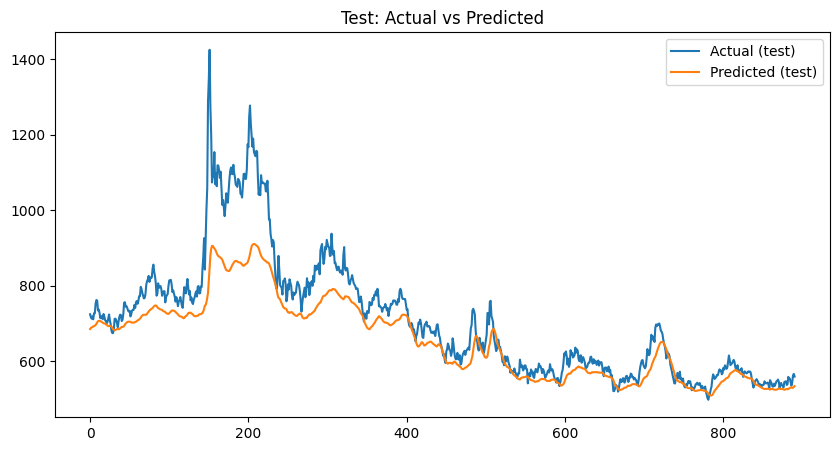


=== Final retrain performance ===
Test RMSE: 83.472804
Test R²  : 0.735127


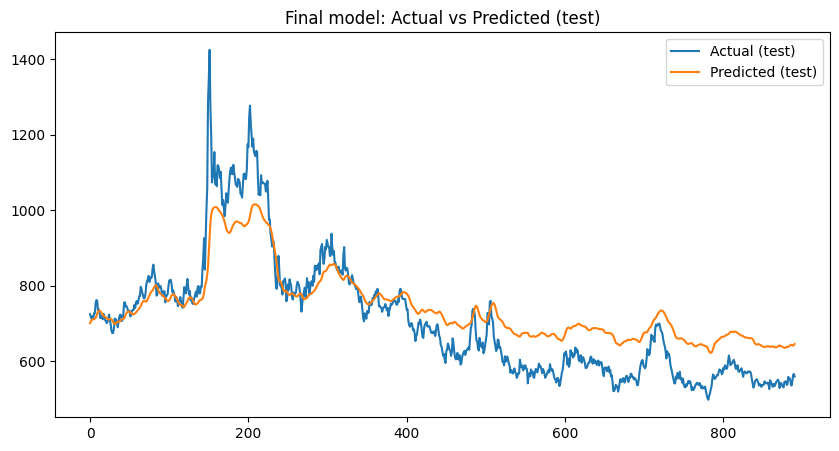

CV metrics: {'rmse': 87.22535289437573, 'r2': 0.7107772800136849}
Final metrics: {'rmse': 83.47280374038642, 'r2': 0.7351274589326727}

=== Train set performance ===
Train RMSE: 32.014168
Train R²  : 0.950460
Train MAE : 24.349542


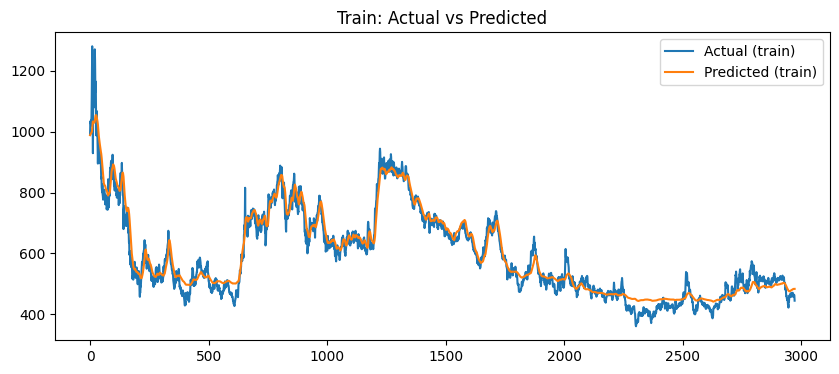


=== Validation set performance ===
Val RMSE: 20.594459
Val R²  : 0.920051
Val MAE : 16.254141


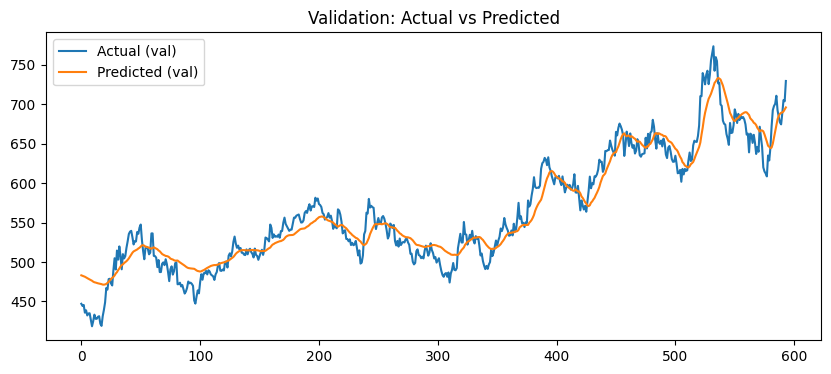


=== Test set performance ===
Test RMSE: 88.023381
Test R²  : 0.705461
Test MAE : 68.062436


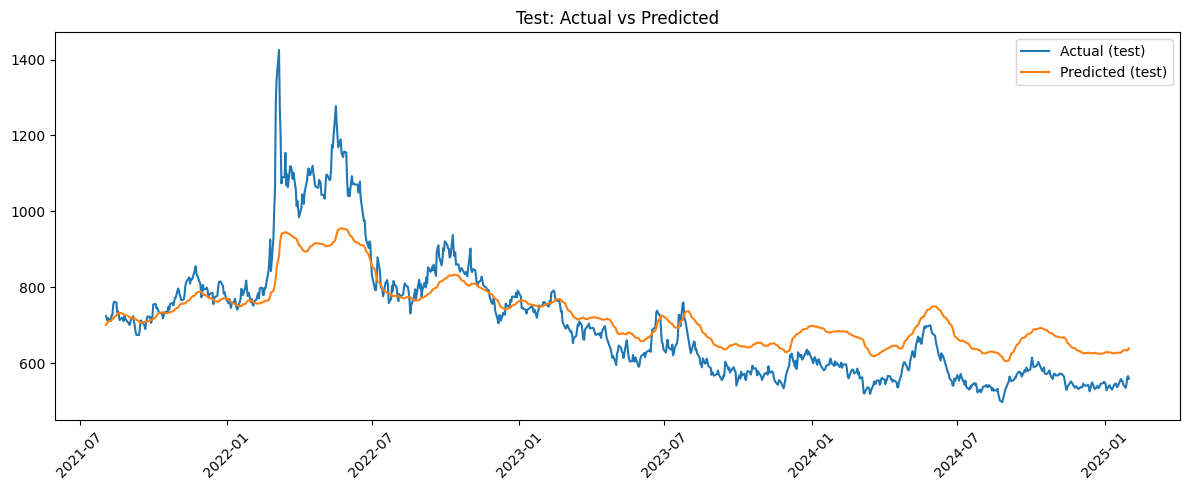

In [ ]:


class TemporalAttentionPooling(layers.Layer):
    def __init__(self, attn_units: int = 64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(attn_units, activation="tanh")
        self.v = layers.Dense(1, activation=None)

    def call(self, x):
        scores = self.v(self.W(x))              # (B, T, 1)
        weights = tf.nn.softmax(scores, axis=1) # (B, T, 1)
        return tf.reduce_sum(weights * x, axis=1)  # (B, C)

def build_rcnn_with_attention(
    seq_length: int,
    feature_dim: int,

    # CNN front-end
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,

    # RNN back-end
    rnn_units: int = 64,
    n_rnn_layers: int = 1,
    encoder_bidirectional: bool = False,

    # Attention pooling
    use_attention: bool = True,
    attn_units: int = 64,

    # Regularization / head
    dropout: float = 0.2,
    kernel_reg: float = 0.02,
    dense_units: int = 128,
    output_activation: str = "linear",

    # kept for signature parity
    learning_rate: float = 1e-3
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))
    x = inputs

    # ---- CNN stack -> (B, T, C)
    for _ in range(n_conv_layers):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(kernel_reg),
        )(x)
        x = layers.Dropout(dropout)(x)

    # ---- GRU stack
    for i in range(n_rnn_layers):
        is_last = (i == n_rnn_layers - 1)

        # if attention is ON, last GRU must return sequences for pooling
        return_seq = True if (not is_last) or use_attention else False

        gru = layers.GRU(
            rnn_units,
            return_sequences=return_seq,
            kernel_regularizer=regularizers.l2(kernel_reg),
        )

        x = layers.Bidirectional(gru)(x) if encoder_bidirectional else gru(x)
        x = layers.Dropout(dropout)(x)

    # ---- Attention pooling over time
    if use_attention:
        x = TemporalAttentionPooling(attn_units=attn_units)(x)  # (B, C)

    # ---- Dense head
    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        1,
        activation=output_activation,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)

    return Model(inputs, outputs)


def cv_rcnn_attention_rmse(
    X_train: np.ndarray,
    y_train: np.ndarray,
    model_builder,

    # architecture hyperparams
    weight_decay: float = 0.02,
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,
    rnn_units: int = 64,
    n_rnn_layers: int = 1,
    attn_units: int = 64,
    dense_units: int = 128,
    dropout: float = 0.2,

    # toggles
    encoder_bidirectional: bool = False,
    use_attention: bool = True,

    # training hyperparams
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3,

    base_seed: int = 1234
) -> float:

    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    fold_rmses = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        K.clear_session()
        gc.collect()
        tf.keras.utils.set_random_seed(base_seed + fold)

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # scalers (your helpers)
        x_scaler = fit_x_scaler_3d(X_tr)
        X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
        X_val_s = transform_x_scaler_3d(x_scaler, X_val)

        y_scaler = fit_y_scaler(y_tr)
        y_tr_s = transform_y(y_scaler, y_tr)
        y_val_s = transform_y(y_scaler, y_val)

        model = model_builder(
            seq_length=lookback,
            feature_dim=n_features,
            filters=filters,
            kernel_size=kernel_size,
            n_conv_layers=n_conv_layers,
            rnn_units=rnn_units,
            n_rnn_layers=n_rnn_layers,
            encoder_bidirectional=encoder_bidirectional,
            use_attention=use_attention,
            attn_units=attn_units,
            dropout=dropout,
            kernel_reg=weight_decay,
            dense_units=dense_units,
        )

        model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss="mean_squared_error"
        )

        early_stop = EarlyStopping(monitor="val_loss", patience=early_stop_patience,
                                   restore_best_weights=True, verbose=0)
        reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                                      min_lr=1e-6, verbose=0)

        model.fit(
            X_tr_s, y_tr_s,
            validation_data=(X_val_s, y_val_s),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        # RMSE on original scale
        y_val_pred_scaled = model.predict(X_val_s, verbose=0).reshape(-1)
        y_val_pred = inverse_y(y_scaler, y_val_pred_scaled)
        fold_rmses.append(float(np.sqrt(mean_squared_error(y_val, y_val_pred))))

        del model

    return float(np.mean(fold_rmses))
def objective(trial):
    # architecture
    weight_decay  = trial.suggest_float("weight_decay", 5e-4, 2e-2, log=True)
    filters       = trial.suggest_categorical("filters", [32, 64, 128])
    kernel_size   = trial.suggest_categorical("kernel_size", [2, 3, 5, 7])
    n_conv_layers = trial.suggest_int("n_conv_layers", 1, 4)

    rnn_units     = trial.suggest_categorical("rnn_units", [32, 64, 128])
    n_rnn_layers  = trial.suggest_int("n_rnn_layers", 1, 3)

    attn_units    = trial.suggest_categorical("attn_units", [16, 32, 64, 128])
    dense_units   = trial.suggest_categorical("dense_units", [32, 64, 128])
    dropout       = trial.suggest_float("dropout", 0.10, 0.30)

    # training
    early_stop_patience = trial.suggest_int("early_stop_patience", 10, 15)
    epochs              = trial.suggest_int("epochs", 50, 200)
    batch_size          = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate       = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)

    return cv_rcnn_attention_rmse(
        X_train=X_train,
        y_train=y_train,
        model_builder=build_rcnn_with_attention,

        weight_decay=weight_decay,
        filters=filters,
        kernel_size=kernel_size,
        n_conv_layers=n_conv_layers,
        rnn_units=rnn_units,
        n_rnn_layers=n_rnn_layers,
        attn_units=attn_units,
        dense_units=dense_units,
        dropout=dropout,

        encoder_bidirectional=False,
        use_attention=True,

        early_stop_patience=early_stop_patience,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
    )

optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))

def print_callback(study, trial):
    print(f"[Trial {trial.number}] value={trial.value:.4f} params={trial.params}", flush=True)

study.optimize(objective, n_trials=50, show_progress_bar=True, callbacks=[print_callback])

print("Best value (CV RMSE):", study.best_value)
print("Best params:", study.best_params)

bp = study.best_params
T, F = X_train.shape[1], X_train.shape[2]

def best_origin_rcnn_attn(encoder_bidirectional=False, use_attention=True):
    return build_rcnn_with_attention(
        seq_length=T, feature_dim=F,
        filters=bp["filters"],
        kernel_size=bp["kernel_size"],
        n_conv_layers=bp["n_conv_layers"],
        rnn_units=bp["rnn_units"],
        n_rnn_layers=bp["n_rnn_layers"],
        attn_units=bp["attn_units"],
        dense_units=bp["dense_units"],
        dropout=bp["dropout"],
        kernel_reg=bp["weight_decay"],
        encoder_bidirectional=encoder_bidirectional,
        use_attention=use_attention,
    )

cv_model, cv_xs, cv_ys, cv_pred, cv_metrics = cv_train_timeseries_model(
    X_train, y_train, X_test, y_test,
    model_origin=best_origin_rcnn_attn,
    use_attention=True,
    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
    plot_test=True
)

final_model, xs, ys, yhat, metrics = train_final_model_and_eval(
    X_train, y_train, X_test, y_test,
    model_origin=best_origin_rcnn_attn,
    use_attention=True,
    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
    plot_test=True
)

print("CV metrics:", cv_metrics)
print("Final metrics:", metrics)
def plot_best_rcnn(
    df_all,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_builder,
    encoder_bidirectional: bool = False,
    use_attention: bool = True,

    # architecture
    weight_decay: float = 0.02,
    filters: int = 64,
    kernel_size: int = 3,
    n_conv_layers: int = 2,
    rnn_units: int = 64,
    n_rnn_layers: int = 1,
    attn_units: int = 64,
    dense_units: int = 128,
    dropout: float = 0.2,

    # training
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3,

    base_seed: int = 1234
):
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    # pick LAST fold
    last_train_idx, last_val_idx = None, None
    for _, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        last_train_idx, last_val_idx = train_idx, val_idx

    X_tr, X_val = X_train[last_train_idx], X_train[last_val_idx]
    y_tr, y_val = y_train[last_train_idx], y_train[last_val_idx]

    # scalers
    x_scaler = fit_x_scaler_3d(X_tr)
    X_tr_s = transform_x_scaler_3d(x_scaler, X_tr)
    X_val_s = transform_x_scaler_3d(x_scaler, X_val)

    y_scaler = fit_y_scaler(y_tr)
    y_tr_s = transform_y(y_scaler, y_tr)
    y_val_s = transform_y(y_scaler, y_val)

    tf.keras.utils.set_random_seed(base_seed)

    model = model_builder(
        seq_length=lookback,
        feature_dim=n_features,
        filters=filters,
        kernel_size=kernel_size,
        n_conv_layers=n_conv_layers,
        rnn_units=rnn_units,
        n_rnn_layers=n_rnn_layers,
        encoder_bidirectional=encoder_bidirectional,
        use_attention=use_attention,
        attn_units=attn_units,
        dropout=dropout,
        kernel_reg=weight_decay,
        dense_units=dense_units,
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="mean_squared_error"
    )

    early_stop = EarlyStopping(monitor="val_loss", patience=early_stop_patience,
                               restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                                  min_lr=1e-6, verbose=0)

    model.fit(
        X_tr_s, y_tr_s,
        validation_data=(X_val_s, y_val_s),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # -------- TRAIN plot
    y_tr_pred_scaled = model.predict(X_tr_s, verbose=0).reshape(-1)
    y_tr_pred = inverse_y(y_scaler, y_tr_pred_scaled)

    print("\n=== Train set performance ===")
    print(f"Train RMSE: {float(np.sqrt(mean_squared_error(y_tr, y_tr_pred))):.6f}")
    print(f"Train R²  : {float(r2_score(y_tr, y_tr_pred)):.6f}")
    print(f"Train MAE : {float(mean_absolute_error(y_tr, y_tr_pred)):.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(y_tr, label="Actual (train)")
    plt.plot(y_tr_pred, label="Predicted (train)")
    plt.title("Train: Actual vs Predicted")
    plt.legend()
    plt.show()

    # -------- VAL plot
    y_val_pred_scaled = model.predict(X_val_s, verbose=0).reshape(-1)
    y_val_pred = inverse_y(y_scaler, y_val_pred_scaled)

    print("\n=== Validation set performance ===")
    print(f"Val RMSE: {float(np.sqrt(mean_squared_error(y_val, y_val_pred))):.6f}")
    print(f"Val R²  : {float(r2_score(y_val, y_val_pred)):.6f}")
    print(f"Val MAE : {float(mean_absolute_error(y_val, y_val_pred)):.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(y_val, label="Actual (val)")
    plt.plot(y_val_pred, label="Predicted (val)")
    plt.title("Validation: Actual vs Predicted")
    plt.legend()
    plt.show()

    # -------- TEST plot (scale test with THIS fold's scalers)
    X_test_s = transform_x_scaler_3d(x_scaler, X_test)
    y_test_pred_scaled = model.predict(X_test_s, verbose=0).reshape(-1)
    y_test_pred = inverse_y(y_scaler, y_test_pred_scaled)

    print("\n=== Test set performance ===")
    print(f"Test RMSE: {float(np.sqrt(mean_squared_error(y_test, y_test_pred))):.6f}")
    print(f"Test R²  : {float(r2_score(y_test, y_test_pred)):.6f}")
    print(f"Test MAE : {float(mean_absolute_error(y_test, y_test_pred)):.6f}")

    if df_all is not None and hasattr(df_all, "index"):
        test_dates = df_all.index[-len(X_test):]
        plt.figure(figsize=(12, 5))
        plt.plot(test_dates, y_test, label="Actual (test)")
        plt.plot(test_dates, y_test_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.legend()
        plt.show()
    else:
        plt.figure(figsize=(12, 5))
        plt.plot(y_test, label="Actual (test)")
        plt.plot(y_test_pred, label="Predicted (test)")
        plt.title("Test: Actual vs Predicted")
        plt.legend()
        plt.show()

    return model
bp = study.best_params

best_model = plot_best_rcnn(
    df_all=df_all,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    model_builder=build_rcnn_with_attention,
    encoder_bidirectional=False,
    use_attention=True,

    weight_decay=bp["weight_decay"],
    filters=bp["filters"],
    kernel_size=bp["kernel_size"],
    n_conv_layers=bp["n_conv_layers"],
    rnn_units=bp["rnn_units"],
    n_rnn_layers=bp["n_rnn_layers"],
    attn_units=bp["attn_units"],
    dense_units=bp["dense_units"],
    dropout=bp["dropout"],

    early_stop_patience=bp["early_stop_patience"],
    epochs=bp["epochs"],
    batch_size=bp["batch_size"],
    learning_rate=bp["learning_rate"],
)
